# Coursework - Part 1 Classification

In [1]:
# import of libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lime.lime_tabular import LimeTabularExplainer
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay
)

# Introduction

Data source - https://www.kaggle.com/datasets/prachi13/customer-analytics/data

This dataset represents an e-commerce company's shipment records. The company wants to predict, ahead of time, whether a given order will arrive late.
The motivation is fundamentally about customer retention. Late deliveries are one of the top reasons customers leave e-commerce platforms — but the damage isn't just the lateness itself. It's whether the customer was surprised by it. If we know in advance a package will be late, we can:

* Proactively notify the customer
* Offer a discount or apology coupon before they complain
* Prioritise certain shipments for upgraded handling
* Identify patterns in logistics that cause delay and fix them  

In [2]:
#import raw data
df = pd.read_csv('./data/raw/Ecommerce.csv')
print(df.shape)

(10999, 12)


The dataset contains 12 columns and 10999 rows.

In [3]:
df.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## Customization

1. *target attribute* - Reached on time Y.N

   
   Justification:
   On-time delivery is a critical performance metric for e-commerce businesses — directly impacting customer satisfaction and retention. Predicting whether a delivery will arrive late enables proactive intervention, making it a high-value classification target.
   
3.	*instance of interest*   id - 4143
4. *attribute of interest* Discount_offered
5.	*Cost matrix*
    |                 |        Predicted: Late       |            Predicted: On Time            |
|:---------------:|:----------------------------:|:----------------------------------------:|
| Actual: Late    | TP = 0     | FN = 10 (missed a late delivery)          |
| Actual: On Time | FP = 2     | TN = 0                          |

Note: The cost matrix above uses the original target encoding where Late=1 (positive class) and On Time=0 (negative class). Labels TP, FP, FN and TN are defined accordingly. After target recoding in preprocessing, an updated cost matrix is provided.

# Data Exploration

1. Describe meaning of individual attributes
2.	Show a histogram (or a table with value frequencies) for the target variable and for selected other variables
3.	Show a scatterplot (correlation plot) showing the relation between selected predictors and the target variable
4.	Interpret the results


In [4]:
#check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [5]:
#check missing values
df.isnull().sum()

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

No missing values found in the dataset. No imputation required.

In [6]:
#check duplicates
df.duplicated().sum()

np.int64(0)

NO duplicate rows found. 

In [7]:
#learn statistical info on numerical fields
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


Found some columns with large standard deviation such as weight, cost of product and discount offered.

In [8]:
#non numerical field info
df.describe(include=object)

,Warehouse_block,Mode_of_Shipment,Product_importance,Gender
count,10999,10999,10999,10999
unique,5,3,3,2
top,F,Ship,low,F
freq,3666,7462,5297,5545


The categorical summary shows that

* Block F dominates most products shipped.
* *Ship* is the dominant mode of shipment, appearing in around 68% of transactions. 
* Product importance - low presents about 48% of transactions.
* Gender is almost balanced between Male and Female. 

### Distributions

In [9]:
# Target variable
df['Reached.on.Time_Y.N'].value_counts(normalize=True)

Reached.on.Time_Y.N
1    0.596691
0    0.403309
Name: proportion, dtype: float64

The target variable shows a slight class imbalance — 6,563 transactions (59.7%) were *NOT* delivered on time compared to 4,436 (40.3%) delivered on time. Although the imbalance is moderate and unlikely to severely bias the model, stratified train-test splitting will be applied to preserve this distribution across both sets.

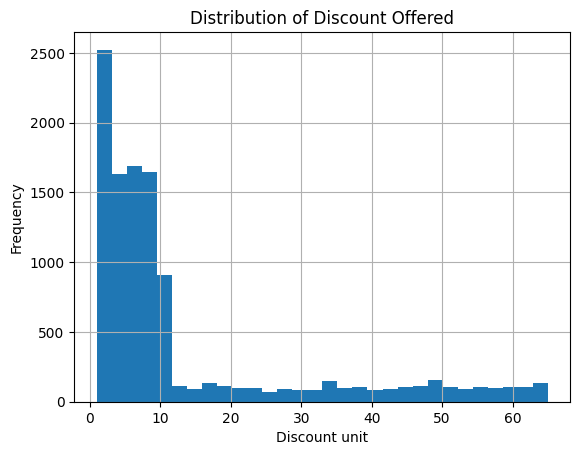

In [10]:
#how is discount offered distributed among dataset.
df['Discount_offered'].hist(bins=30)
plt.title("Distribution of Discount Offered")
plt.xlabel("Discount unit")
plt.ylabel("Frequency")
plt.show()

We can see that low discount (1-10) are more common in the dataset. There are some outlier values above 60 too.  

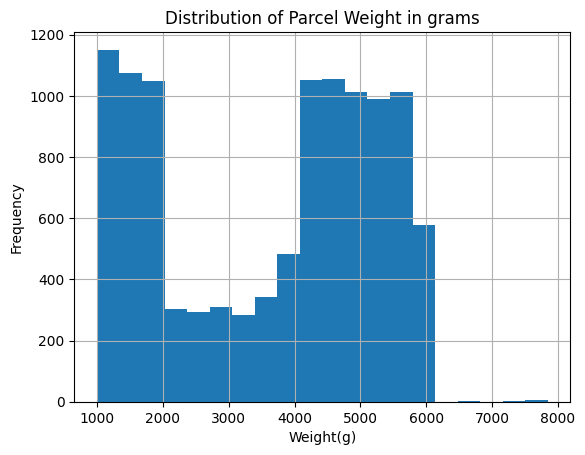

In [11]:
df['Weight_in_gms'].hist(bins=20)
plt.title('Distribution of Parcel Weight in grams')
plt.xlabel('Weight(g)')
plt.ylabel('Frequency')
plt.show()

The distribution of Weight_in_gms reveals two distinct clusters — lightweight products (1,000–2,000g) and heavier products (4,000–6,000g). Values above 7,000g appear infrequently and may represent outliers worth investigating during preprocessing.

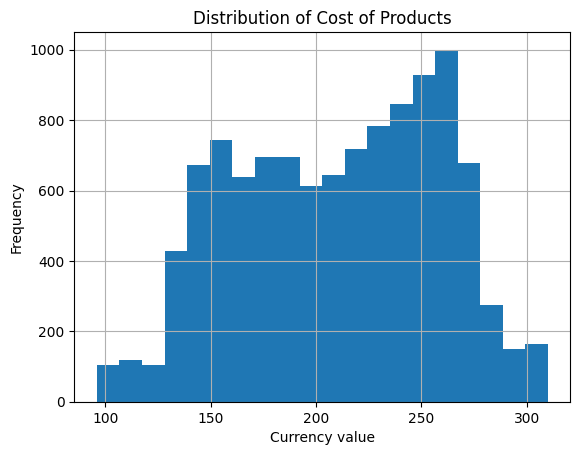

In [12]:
#COST of products
df['Cost_of_the_Product'].hist(bins=20)
plt.title('Distribution of Cost of Products')
plt.xlabel('Currency value')
plt.ylabel('Frequency')
plt.show()

The distribution of product costs ranges from around 100 to just above 300 currency units. It is approximately uniform across the mid-range (150–280), with a slight concentration around 250–270. Products below 130 units are relatively rare, suggesting most products fall within a moderate price range.

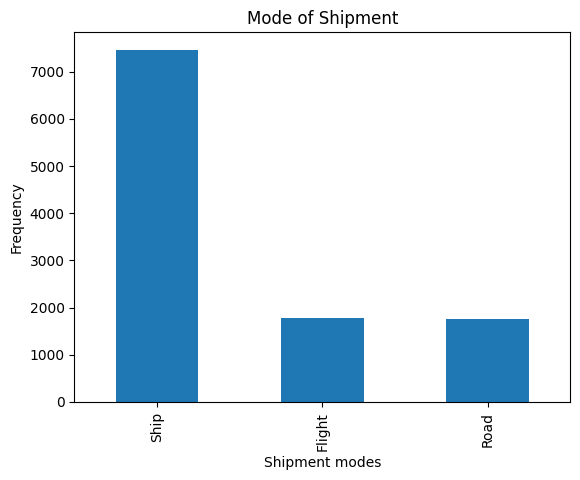

In [13]:
#moode of shipment is important for delivery. 
df['Mode_of_Shipment'].value_counts().plot(kind='bar')	
plt.title('Mode of Shipment')
plt.xlabel('Shipment modes')
plt.ylabel('Frequency')
plt.show()

Mode of shipment is dominated by Ship (68%), with Flight and Road representing smaller proportions. This skew in the predictor may limit the model's ability to generalise patterns for less frequent shipping modes.

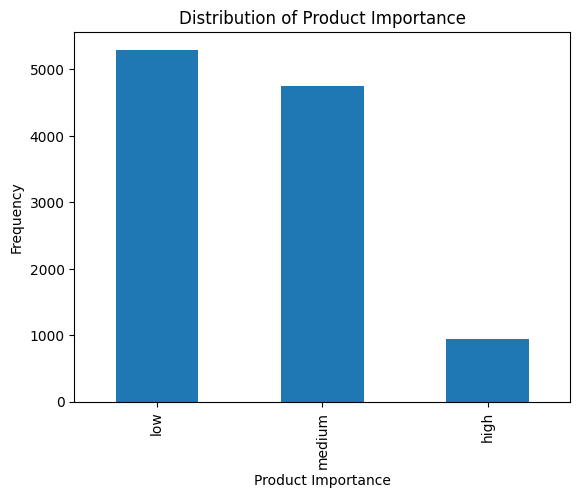

Product_importance
low       48.158924
medium    43.222111
high       8.618965
Name: proportion, dtype: float64

In [14]:
#Product importance 
df['Product_importance'].value_counts().plot(kind='bar')
plt.title('Distribution of Product Importance')
plt.xlabel('Product Importance')
plt.ylabel('Frequency')
plt.show()

df['Product_importance'].value_counts(normalize=True) * 100


High importance products represent only around 9% of the dataset, while low and medium importance products dominate. This skew in the predictor may limit the model's ability to generalise patterns for high importance products, as it will see fewer examples of this category during training.

<Axes: >

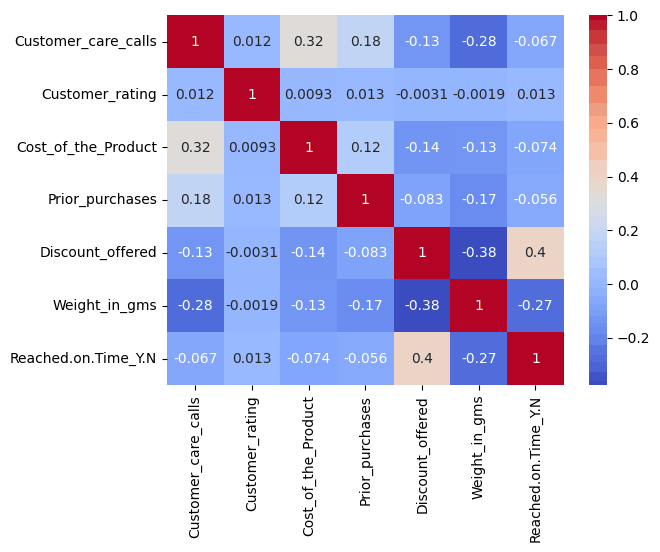

In [15]:
#correlation matrix

df_temp = df.drop(columns=['ID']) #drops ID column

sns.heatmap(df_temp.select_dtypes("number").corr(), 
            annot=True, cmap="coolwarm")

*Discount_offered* shows the strongest positive correlation (0.4) with the target — higher discounts are associated with late delivery. *Weight_in_gms* shows a moderate negative correlation (-0.27) — heavier packages are more likely to arrive on time. These counterintuitive findings warrant further investigation during modelling.

On the other hand, all other numeric predictors show negligible correlation with the target (below 0.1), suggesting limited linear predictive power individually.

,count,mean,std,min,25%,50%,75%,max
Reached.on.Time_Y.N,,,,,,,,
0,4436.0,5.545987,2.877727,1.0,3.0,6.0,8.0,10.0
1,6563.0,18.663721,19.108797,1.0,5.0,9.0,32.0,65.0


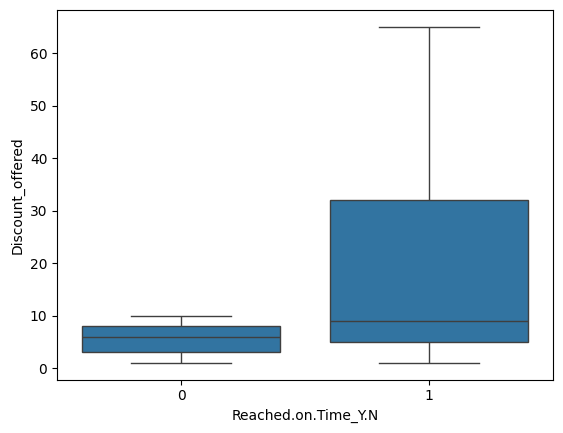

In [16]:
#does discount affect delivery timeliness?
sns.boxplot(x="Reached.on.Time_Y.N", y="Discount_offered", data=df)
df.groupby("Reached.on.Time_Y.N")["Discount_offered"].describe()

The boxplot confirms the correlation finding — packages delivered on time (0) received significantly lower discounts (median ~6), while late deliveries (1) were associated with much higher discounts (median ~9, IQR spanning 5–32). This suggests that heavily discounted products are more likely to experience delivery delays, possibly indicating higher demand or logistic challenges for promotional items.

,count,mean,std,min,25%,50%,75%,max
Reached.on.Time_Y.N,,,,,,,,
0,4436.0,4168.668395,1573.954178,1001.0,4043.5,4674.0,5337.0,6000.0
1,6563.0,3272.640104,1576.148391,1001.0,1735.5,3231.0,4696.5,7846.0


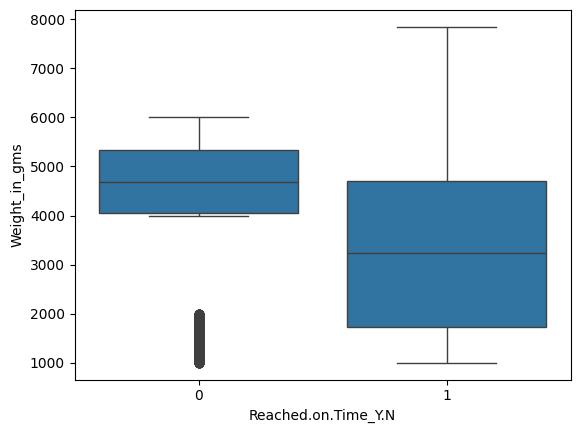

In [17]:
#does discount affect delivery timeliness?
sns.boxplot(x="Reached.on.Time_Y.N", y="Weight_in_gms", data=df)

df.groupby("Reached.on.Time_Y.N")["Weight_in_gms"].describe()

The boxplot reveals that packages delivered on time (0) tend to be heavier, with an IQR spanning approximately 4,000–6,000g. In contrast, late deliveries (1) are associated with lighter packages, with an IQR of approximately 2,000–4,700g. This suggests that logistics operations may be better optimised for handling heavier shipments, while smaller and lighter packages experience more delays. However, this relationship may also reflect confounding factors such as product type or shipping route.

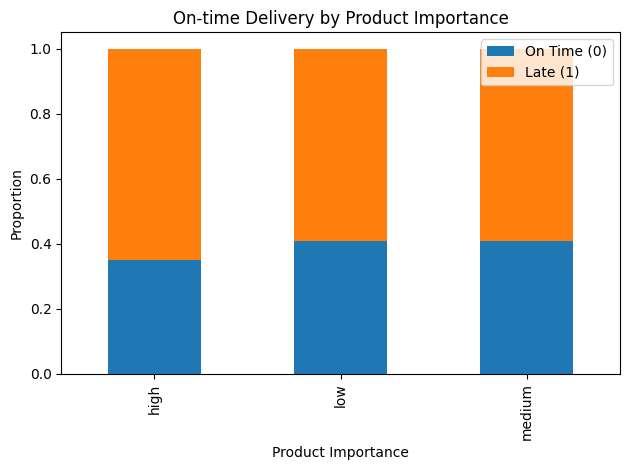

In [18]:
#Does product importance influence delivery?
pd.crosstab(df["Product_importance"], 
            df["Reached.on.Time_Y.N"], 
            normalize="index").plot(kind="bar", stacked=True)

plt.title("On-time Delivery by Product Importance")
plt.xlabel("Product Importance")
plt.ylabel("Proportion")
plt.legend(["On Time (0)", "Late (1)"])
plt.tight_layout()
plt.show()

The stacked bar chart shows that the proportion of on-time vs late deliveries remains largely consistent across all three product importance levels — approximately 35–40% on time and 60–65% late regardless of importance. This suggests that product importance has minimal influence on delivery timeliness and is unlikely to be a strong predictor in the model.

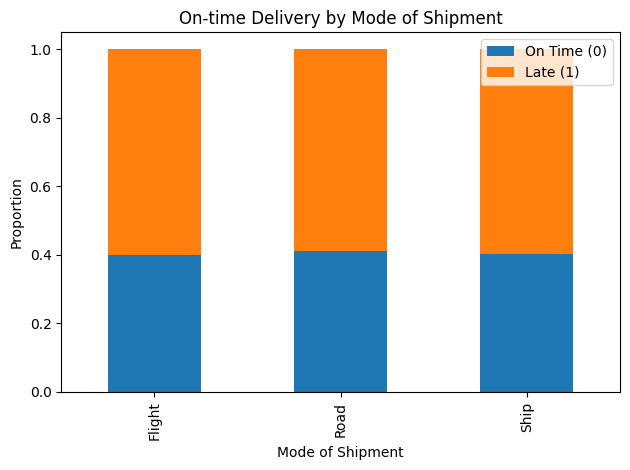

In [19]:
#Does shipping mode influence delivery?
pd.crosstab(df["Mode_of_Shipment"], 
            df["Reached.on.Time_Y.N"], 
            normalize="index").plot(kind="bar", stacked=True)

plt.title("On-time Delivery by Mode of Shipment")
plt.xlabel("Mode of Shipment")
plt.ylabel("Proportion")
plt.legend(["On Time (0)", "Late (1)"])
plt.tight_layout()
plt.show()

Despite expectations that shipment mode would influence delivery timeliness, the stacked bar chart shows a consistent 40-60 split across all modes. This counterintuitive finding may reflect the synthetic nature of the dataset or suggest that other factors such as discount and package weight are stronger determinants of delivery outcome.

In [20]:
# Check potential data leakage columns
leakage_check = df.groupby("Reached.on.Time_Y.N")[["Customer_care_calls", 
                                        "Customer_rating", 
                                        "Prior_purchases"]].mean()
print(leakage_check)

                     Customer_care_calls  Customer_rating  Prior_purchases
Reached.on.Time_Y.N                                                       
0                               4.147656         2.967989         3.670424
1                               3.991467         3.005790         3.498095


Three columns were examined for potential data leakage — Customer_care_calls, Customer_rating and Prior_purchases. Mean values were compared across delivery outcome classes. All three showed negligible differences between late (1) and on-time (0) deliveries, confirming they reflect pre-delivery customer behaviour rather than post-delivery outcomes

### Conclusion
In summary, EDA revealed that Discount_offered and Weight_in_gms are the strongest numeric predictors of delivery timeliness. Categorical variables including Product_importance and Mode_of_Shipment show limited influence on the target variable. The target variable shows a moderate 60-40 class imbalance favouring late deliveries. These findings will inform feature selection and preprocessing decisions in the following section.

# Data preprocessing

## Preprocessing for supervised machine learning 

In [21]:
#copy instance of interest
instance_ID = 4143 #chosen instance
instance_of_interest = df[df["ID"] == instance_ID].copy()
print(instance_of_interest)

        ID Warehouse_block Mode_of_Shipment  Customer_care_calls  \
4142  4143               A             Ship                    3   

      Customer_rating  Cost_of_the_Product  Prior_purchases  \
4142                1                  149                2   

     Product_importance Gender  Discount_offered  Weight_in_gms  \
4142             medium      F                 7           4147   

      Reached.on.Time_Y.N  
4142                    1  


### Derive binary target attribute (if not already binary)

The original target variable Reached.on.Time_Y.N was encoded as 1 = late delivery and 0 = on-time delivery. To improve interpretability, the variable was recoded by inverting the values — the new variable On_Time is set to 1 for on-time delivery (positive class) and 0 for late delivery (negative class).

In [22]:
#1 = On Time (positive outcome)
#0 = Late (negative outcome)
df["On_Time"] = 1 - df["Reached.on.Time_Y.N"]
df = df.drop(columns = ["Reached.on.Time_Y.N"])
target_variable = "On_Time"


### Train test split 

In [23]:
#drop ID column 
df = df.drop(columns = ["ID"])
print(df.columns)

X, y = df.loc[:, df.columns != target_variable], df[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

Index(['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'On_Time'],
      dtype='object')


Data was split into 80% training and 20% test sets using stratified sampling to preserve the 60-40 class distribution across both sets. Shuffling was applied during splitting to prevent ordering bias.

### Feature engineering 

Do at least one additional data preprocessing, such as

-	Remove missing values
-	If the classes are imbalanced, you may upsample (or downsample) the training dataset.
-	Normalize values or use a standard scale 
-	Remove rows based on subsetting
-	Derive new columns
-	Perform feature selection (remove some attributes)

Make sure that your preprocessing operation does not use information from the test set. It is therefore recommended to “fit” preprocessing on the training set and then apply it on the test set.

Two derived features were added to create an augmented dataset (v2). Cost_per_gram captures value density — the ratio of product cost to weight — as expensive lightweight items may require special handling that contributes to delivery delays. Weight_category was derived by binning Weight_in_gms into three groups (light, medium, heavy), motivated by the bimodal weight distribution identified in EDA. Both features were evaluated for their impact on model performance relative to the original feature set.

#### Preprocessing on training data

In [24]:
#perform one hot encoding for nominal data
X_train = pd.get_dummies(X_train, columns = ['Warehouse_block', 'Mode_of_Shipment', 'Gender'])

#mapping for ordinal data - Product importance
importance_map = {"low" : 0, "medium" : 1, "high": 2}
X_train["Product_importance"] = X_train["Product_importance"].map(importance_map)


#introducing new columns here and keep them as separate training sources
X_train_v1 = X_train.copy() #original df
X_train_v2 = X_train.copy() #df with new columns

#new columns
X_train_v2["Cost_per_gram"] = X_train_v2["Cost_of_the_Product"] / X_train_v2["Weight_in_gms"]

weight_map = {"light": 0, "medium": 1, "heavy": 2}
X_train_v2["Weight_category"] = pd.cut(X_train_v2["Weight_in_gms"],
                                bins=[0, 2000, 4000, 8000],
                                labels=["light", "medium", "heavy"]).map(weight_map)

#standard scaler
scaler_1 = StandardScaler()
scaler_2 = StandardScaler()
X_train_v1_scaled = scaler_1.fit_transform(X_train_v1)
X_train_v1_scaled = pd.DataFrame(X_train_v1_scaled, columns=X_train_v1.columns)

X_train_v2_scaled = scaler_2.fit_transform(X_train_v2)
X_train_v2_scaled = pd.DataFrame(X_train_v2_scaled, columns=X_train_v2.columns)

## Applying preprocessing on test data

In [25]:
#perform exact preprocessing as training data
X_test = pd.get_dummies(X_test, columns = ['Warehouse_block', 'Mode_of_Shipment', 'Gender'])

#encode ordinal data
X_test['Product_importance'] = X_test['Product_importance'].map(importance_map)
#align with training columns
X_test = X_test.reindex(columns = X_train.columns, fill_value = 0)

#introducing new columns here and keep them as separate training sources
X_test_v1 = X_test.copy() #original df
X_test_v2 = X_test.copy() #df with new columns

#new columns
X_test_v2["Cost_per_gram"] = X_test_v2["Cost_of_the_Product"] / X_test_v2["Weight_in_gms"]

X_test_v2["Weight_category"] = pd.cut(X_test_v2["Weight_in_gms"],
                                bins=[0, 2000, 4000, 8000],
                                labels=["light", "medium", "heavy"]).map(weight_map)




#apply standard scaler on test data
X_test_v1_scaled = scaler_1.transform(X_test_v1)
X_test_v1_scaled = pd.DataFrame(X_test_v1_scaled, columns = X_test_v1.columns)

X_test_v2_scaled = scaler_2.transform(X_test_v2)
X_test_v2_scaled = pd.DataFrame(X_test_v2_scaled, columns = X_test_v2.columns)

In [26]:
#checking to ensure alignment
print(X_train_v1_scaled.shape)
print(X_test_v1_scaled.shape)

print(X_train_v2_scaled.shape)
print(X_test_v2_scaled.shape)
print(y_train.shape)
print(y_test.shape)

#checking NaN values
print(X_train_v1_scaled.isnull().sum().sum())
print(X_test_v1_scaled.isnull().sum().sum())

print(X_train_v2_scaled.isnull().sum().sum())
print(X_test_v2_scaled.isnull().sum().sum())

(8799, 17)
(2200, 17)
(8799, 19)
(2200, 19)
(8799,)
(2200,)
0
0
0
0


##### Saving data

In [27]:
#original train/test data
train_v1_out = X_train_v1_scaled.copy()
train_v1_out["On_Time"] = y_train.values
train_v1_out.to_csv("./data/train_v1.csv", index=False)

test_v1_out = X_test_v1_scaled.copy()
test_v1_out["On_Time"] = y_test.values
test_v1_out.to_csv("./data/test_v1.csv", index=False)

#dataset 2
train_v2_out = X_train_v2_scaled.copy()
train_v2_out["On_Time"] = y_train.values
train_v2_out.to_csv("./data/train_v2.csv", index=False)

test_v2_out = X_test_v2_scaled.copy()
test_v2_out["On_Time"] = y_test.values
test_v2_out.to_csv("./data/test_v2.csv", index=False)


## Modeling

* Train the model on training data, and evaluate the model on test data. 
* Try at least two machine learning classification algorithms. It is recommended to try Decision Trees and Forests. 


### Classifier 1 (decision tree)

* Try various combinations of metaparameters (such as tree depth for decision tree) and record the impact on predictive performance. You can use grid search cross-validation for this.
* Once you determine the best values, you can refit the model with the best parameter value on the entire training data.

### Classifier 2 (random forest)

* Try various combinations of metaparameters (such as  number of trees in a forest) and record the impact on predictive performance. You can use grid search cross-validation for this.
* Once you determine the best values, you can refit the model with the best parameter value on the entire training data.


### Classifier 3 (baseline)

* Fit a baseline model, e.g., a model that predicts the most frequent class in the training data

#### Classifier 1 - Decision Tree

##### Modeling

In [28]:
#prepare empty map
results = {
    "DecisionTree": {},
    "RandomForest": {},
    "Dummy":{}
}
#define metrics
def evaluate_classifier(y_true, y_pred, y_prob, cost_matrix):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob),
        "recall_0": tn / (tn + fp) if (tn + fp) else 0,
        "total_cost": np.sum(cm * cost_matrix),
    }
  
    return metrics, cm

In [29]:
#build decision tree classifier
clf_dt = DecisionTreeClassifier(random_state = 42)
clf_dt.fit(X_train_v1_scaled, y_train)

DecisionTreeClassifier(random_state=42)

##### Evaluation

*Updated Cost matrix after flipping target variable*

|                    | Predicted: On Time              | Predicted: Late                        |
|:------------------:|:-------------------------------:|:--------------------------------------:|
| Actual: On Time    | TP = 0 (correct)                | FN = 2 (unnecessary intervention)      |
| Actual: Late       | FP = 10 (missed late delivery)  | TN = 0 (correct)                       |

In [30]:
cost_matrix = np.array([
    [0,  10],   # TN cost, FP cost
    [2, 0]    # FN cost, TP cost
])

              precision    recall  f1-score   support

           0       0.70      0.70      0.70      1313
           1       0.55      0.55      0.55       887

    accuracy                           0.64      2200
   macro avg       0.62      0.62      0.62      2200
weighted avg       0.64      0.64      0.64      2200



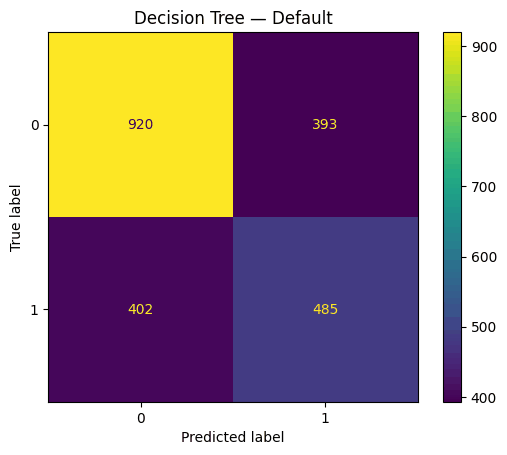

Metrics:
{'accuracy': 0.6386363636363637, 'precision': 0.5523917995444191, 'recall': 0.5467869222096956, 'f1': 0.5495750708215298, 'auc': np.float64(0.6237361876851982), 'recall_0': np.float64(0.7006854531607006), 'total_cost': np.int64(4734)}
TN: 920, FP: 393, FN: 402, TP: 485


In [31]:
#apply classifier
y_pred_dt_default = clf_dt.predict(X_test_v1_scaled)
y_prob_dt_default = clf_dt.predict_proba(X_test_v1_scaled)[:,1]


dt_default_metrics, cm_dt_default = evaluate_classifier(
    y_test,
    y_pred_dt_default,
    y_prob_dt_default,
    cost_matrix
)
results["DecisionTree"]["default_v1"] = dt_default_metrics

print(classification_report(y_test, y_pred_dt_default))

cm_display = ConfusionMatrixDisplay(cm_dt_default).plot()
plt.title("Decision Tree — Default")
plt.show()
print("Metrics:")
print(dt_default_metrics)
tn, fp, fn, tp = cm_dt_default.ravel()
print(f"TN: {str(tn)}, FP: {str(fp)}, FN: {str(fn)}, TP: {str(tp)}")


Default decision tree gives a total cost of 4734 but the auc score is only marginally better than random classifier (auc = 0.5).

#### Hyperparameter Tuning

Grid search was optimised for f1 score which is a standard metric used to optimize.

In [32]:
param_grid = {
    "max_depth": [3, 5, 10, 15],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 5, 10]
}


grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,           # 5-fold cross validation
    scoring="f1"    # optimize for f1 score 
)

grid_search.fit(X_train_v1_scaled, y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2}
0.7057524718620666


In [33]:
# dt configuration for optimized F1
dt_tuned = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42,
    min_samples_split= 2
)

dt_tuned.fit(X_train_v1_scaled, y_train)
y_pred_dt_f1_v1 = dt_tuned.predict(X_test_v1_scaled) 
y_prob_dt_f1_v1 = dt_tuned.predict_proba(X_test_v1_scaled)[:,1]

dt_f1_metrics, cm_dt_f1 = evaluate_classifier(
    y_test,
    y_pred_dt_f1_v1,
    y_prob_dt_f1_v1,
    cost_matrix
)
results["DecisionTree"]["f1_v1"] = dt_f1_metrics
print(classification_report(y_test, y_pred_dt_f1_v1))
tn, fp, fn, tp = cm_dt_f1.ravel()
print(f"TN: {str(tn)}, FP: {str(fp)}, FN: {str(fn)}, TP: {str(tp)}")
print(f"Total cost: {results['DecisionTree']['f1_v1']['total_cost']}")

              precision    recall  f1-score   support

           0       0.93      0.48      0.63      1313
           1       0.55      0.95      0.70       887

    accuracy                           0.67      2200
   macro avg       0.74      0.71      0.67      2200
weighted avg       0.78      0.67      0.66      2200

TN: 628, FP: 685, FN: 44, TP: 843
Total cost: 6938


In [34]:
# Combine into comparison table
comparison = pd.DataFrame({
    "Metric":   list(results['DecisionTree']['default_v1'].keys()),
    "Default Model": list(results['DecisionTree']['default_v1'].values()),
    "F1 optimized":   list(results['DecisionTree']['f1_v1'].values())
})

comparison.round(3)


,Metric,Default Model,F1 optimized
0,accuracy,0.639,0.669
1,precision,0.552,0.552
2,recall,0.547,0.950
3,f1,0.550,0.698
4,auc,0.624,0.725
5,recall_0,0.701,0.478
6,total_cost,4734.000,6938.000


Hyperparameter tuning improved standard metrics (F1: 0.55→0.698, AUC: 0.624→0.725) but increased total business cost from 4,734 to 6938. The tuned model's high recall (0.95) resulted in more false positives — the most expensive error type in this context (cost=10). This demonstrates that optimising for standard ML metrics does not always align with business objectives, highlighting the importance of cost-sensitive model evaluation.

In [35]:

def cost_scorer(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return -np.sum(cm * cost_matrix)  # negative because GridSearch maximizes

cost_scoring = make_scorer(cost_scorer)

grid_search_cost = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    scoring=cost_scoring,
    cv=5
)

grid_search_cost.fit(X_train_v1_scaled, y_train)
y_pred_dt_cost_v1 = grid_search_cost.predict(X_test_v1_scaled)
y_prob_dt_cost_v1 = grid_search_cost.predict_proba(X_test_v1_scaled)[:,1]


print("Best params:", grid_search_cost.best_params_)

dt_cost_metrics, cm_dt_cost = evaluate_classifier(
    y_test,
    y_pred_dt_cost_v1,
    y_prob_dt_cost_v1,
    cost_matrix
)

results["DecisionTree"]["cost_v1"] = dt_cost_metrics

print(classification_report(y_test, y_pred_dt_cost_v1))
tn, fp, fn, tp = cm_dt_cost.ravel()
print(f"TN: {str(tn)}, FP: {str(fp)}, FN: {str(fn)}, TP: {str(tp)}")
print(f"Total cost: {results['DecisionTree']['cost_v1']['total_cost']}")



Best params: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 5}
              precision    recall  f1-score   support

           0       0.75      0.64      0.69      1313
           1       0.56      0.68      0.62       887

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200

TN: 843, FP: 470, FN: 282, TP: 605
Total cost: 5264


In [36]:
dt_comparison = pd.DataFrame({
    "Metric":   list(results['DecisionTree']['default_v1'].keys()),
    "Default Model": list(results['DecisionTree']['default_v1'].values()),
    "F1 optimized":   list(results['DecisionTree']['f1_v1'].values()),
    "Cost optimized": list(results['DecisionTree']['cost_v1'].values())
})
dt_comparison.round(3)


,Metric,Default Model,F1 optimized,Cost optimized
0,accuracy,0.639,0.669,0.658
1,precision,0.552,0.552,0.563
2,recall,0.547,0.950,0.682
3,f1,0.550,0.698,0.617
4,auc,0.624,0.725,0.712
5,recall_0,0.701,0.478,0.642
6,total_cost,4734.000,6938.000,5264.000


Three Decision Tree configurations were evaluated. The f1-optimised model achieved best performance across all standard metrics (accuracy=0.669, F1=0.698, AUC=0.725). However, the default model produced the lowest business cost (4,734) due to conservative predictions resulting in fewer false positives. The cost-optimised model offered a compromise — improving recall balance at moderate cost (5,264). Although the default model achieved the lowest total cost (4,734), this was coincidental rather than by design. The cost-optimised model (total cost=5,264) was selected as the final Decision Tree as it was explicitly tuned to minimise business cost, producing more balanced predictions across both classes.

In [37]:
#using cost optimized version
dt_cost_optimized_unscaled = grid_search_cost.best_estimator_

## Is there any difference between using scaled vs unscaled dataset?

dt_cost_optimized_unscaled.fit(X_train_v1, y_train)
y_pred_dt_cost_unscaled_v1 = dt_cost_optimized_unscaled.predict(X_test_v1) 
y_prob_dt_cost_unscaled_v1 = dt_cost_optimized_unscaled.predict_proba(X_test_v1)[:,1]

dt_cost_unscaled_metrics, cm_dt_cost_unscaled = evaluate_classifier(
    y_test,
    y_pred_dt_cost_unscaled_v1,
    y_prob_dt_cost_unscaled_v1,
    cost_matrix
)

results["DecisionTree"]["cost_v1_unscaled"] = dt_cost_unscaled_metrics

print(classification_report(y_test, y_pred_dt_cost_unscaled_v1))
tn, fp, fn, tp = cm_dt_cost_unscaled.ravel()
print(f"TN: {str(tn)}, FP: {str(fp)}, FN: {str(fn)}, TP: {str(tp)}")
print(f"Total cost: {results['DecisionTree']['cost_v1_unscaled']['total_cost']}")

              precision    recall  f1-score   support

           0       0.75      0.64      0.69      1313
           1       0.56      0.68      0.62       887

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200

TN: 843, FP: 470, FN: 282, TP: 605
Total cost: 5264


In [38]:
## Is there any difference between using scaled vs unscaled dataset?
# Combine into comparison table

dt_comparison = pd.DataFrame({
    "Metric":   list(results['DecisionTree']['default_v1'].keys()),
    "Cost Scaled": list(results['DecisionTree']['cost_v1'].values()),
    "Cost Unscaled": list(results['DecisionTree']['cost_v1_unscaled'].values())
})
dt_comparison.round(3)


,Metric,Cost Scaled,Cost Unscaled
0,accuracy,0.658,0.658
1,precision,0.563,0.563
2,recall,0.682,0.682
3,f1,0.617,0.617
4,auc,0.712,0.712
5,recall_0,0.642,0.642
6,total_cost,5264.000,5264.000


Feature scaling has no effect on Decision Tree performance as the algorithm makes decisions based on threshold splits on individual features rather than distances between instances. Scaling preserves the relative order of values and therefore does not alter which threshold produces the optimal split — resulting in identical performance on scaled and unscaled data. Therefore, unscaled data was used in decision tree visualization later to improve threshold readability.

#### Feature Finetuning

In [39]:
dt_cost_optimized = grid_search_cost.best_estimator_
dt_cost_optimized.fit(X_train_v1_scaled, y_train)

dt_importances = pd.Series(
      dt_cost_optimized.feature_importances_,
      index=X_train_v1_scaled.columns).sort_values(ascending=True)
print(dt_importances)

Gender_F                   0.003084
Warehouse_block_D          0.004524
Gender_M                   0.004779
Mode_of_Shipment_Road      0.004874
Mode_of_Shipment_Ship      0.005563
Warehouse_block_C          0.005665
Warehouse_block_A          0.007115
Warehouse_block_B          0.009305
Mode_of_Shipment_Flight    0.011079
Product_importance         0.012115
Warehouse_block_F          0.014852
Customer_rating            0.024793
Customer_care_calls        0.032569
Prior_purchases            0.058313
Cost_of_the_Product        0.105371
Weight_in_gms              0.212318
Discount_offered           0.483683
dtype: float64


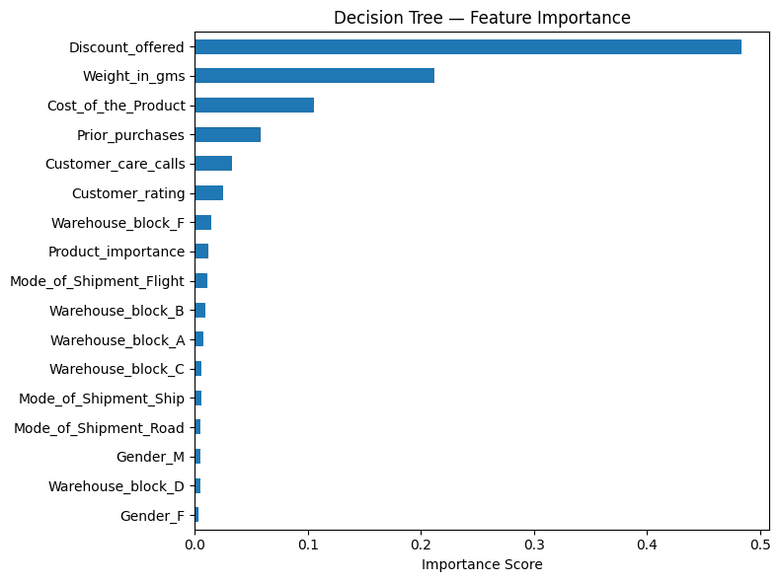

In [40]:
dt_importances.plot(kind="barh", figsize=(8, 6))
plt.title("Decision Tree — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [41]:
# Keep features above threshold
threshold_dt = 0.01  # adjust based on output
selected_features = dt_importances[dt_importances > threshold_dt].index.tolist()
print("Selected features:", selected_features)
print("Dropped features:", dt_importances[dt_importances <= threshold_dt].index.tolist())

# Create reduced datasets
X_train_v1_reduced = X_train_v1_scaled[selected_features]
X_test_v1_reduced = X_test_v1_scaled[selected_features]

Selected features: ['Mode_of_Shipment_Flight', 'Product_importance', 'Warehouse_block_F', 'Customer_rating', 'Customer_care_calls', 'Prior_purchases', 'Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered']
Dropped features: ['Gender_F', 'Warehouse_block_D', 'Gender_M', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Ship', 'Warehouse_block_C', 'Warehouse_block_A', 'Warehouse_block_B']


In [42]:
dt_cost_optimized.fit(X_train_v1_reduced, y_train)

y_pred_reduced_v1 = dt_cost_optimized.predict(X_test_v1_reduced)
y_prob_reduced_v1 = dt_cost_optimized.predict_proba(X_test_v1_reduced)[:,1]


dt_cost_reduced_metrics, cm_dt_cost_reduced = evaluate_classifier(
    y_test,
    y_pred_reduced_v1,
    y_prob_reduced_v1,
    cost_matrix
)

results["DecisionTree"]["cost_v1_reduced"] = dt_cost_reduced_metrics

print(classification_report(y_test, y_pred_reduced_v1))
tn, fp, fn, tp = cm_dt_cost_reduced.ravel()
print(f"TN: {str(tn)}, FP: {str(fp)}, FN: {str(fn)}, TP: {str(tp)}")
print(f"Total cost: {results['DecisionTree']['cost_v1_reduced']['total_cost']}")


dt_comparison = pd.DataFrame({
    "Metric":   list(results['DecisionTree']['default_v1'].keys()),
    "Cost V1": list(results['DecisionTree']['cost_v1'].values()),
    "Cost Reduced V1": list(results['DecisionTree']['cost_v1_reduced'].values())
})
dt_comparison.round(3)



              precision    recall  f1-score   support

           0       0.75      0.65      0.70      1313
           1       0.57      0.69      0.62       887

    accuracy                           0.67      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200

TN: 856, FP: 457, FN: 279, TP: 608
Total cost: 5128


,Metric,Cost V1,Cost Reduced V1
0,accuracy,0.658,0.665
1,precision,0.563,0.571
2,recall,0.682,0.685
3,f1,0.617,0.623
4,auc,0.712,0.716
5,recall_0,0.642,0.652
6,total_cost,5264.000,5128.000


Feature selection using a 0.01 importance threshold produced small differences in standard metrics but reduced total business cost from 5,264 to 5,128. This suggests that removing low-importance features eliminates marginal noise in decision boundaries, directly reducing false positives. The reduced feature model with selected feature reduction is therefore selected as the optimized model so far.

### Using dataset with derived features

In [43]:
# Train best DT config on v2

dt_cost_optimized_v2 = grid_search_cost.best_estimator_
dt_cost_optimized_v2.fit(X_train_v2_scaled, y_train)
y_pred_cost_v2 = dt_cost_optimized_v2.predict(X_test_v2_scaled)
y_prob_cost_v2 = dt_cost_optimized_v2.predict_proba(X_test_v2_scaled)[:,1]

dt_cost_v2_metrics, cm_dt_cost_v2 = evaluate_classifier(
    y_test,
    y_pred_cost_v2,
    y_prob_cost_v2,
    cost_matrix
)

results["DecisionTree"]["cost_v2"] = dt_cost_v2_metrics

print(classification_report(y_test, y_pred_cost_v2))
tn, fp, fn, tp = cm_dt_cost_v2.ravel()
print(f"TN: {str(tn)}, FP: {str(fp)}, FN: {str(fn)}, TP: {str(tp)}")
print(f"Total cost: {results['DecisionTree']['cost_v2']['total_cost']}")


dt_comparison = pd.DataFrame({
    "Metric":   list(results['DecisionTree']['default_v1'].keys()),
    "Original Data": list(results['DecisionTree']['cost_v1'].values()),
    "Added Features": list(results['DecisionTree']['cost_v2'].values())
})
dt_comparison.round(3)


              precision    recall  f1-score   support

           0       0.75      0.65      0.69      1313
           1       0.56      0.67      0.61       887

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200

TN: 852, FP: 461, FN: 289, TP: 598
Total cost: 5188


,Metric,Original Data,Added Features
0,accuracy,0.658,0.659
1,precision,0.563,0.565
2,recall,0.682,0.674
3,f1,0.617,0.615
4,auc,0.712,0.708
5,recall_0,0.642,0.649
6,total_cost,5264.000,5188.000


The augmented feature set (v2) including Cost_per_gram and Weight_category produced near-identical standard metrics compared to the original feature set (v1) — differences across accuracy, F1 and AUC were negligible (≤0.004). However, v2 achieved a lower total business cost (5,188 vs 5,264), suggesting that the derived features marginally improved the model's ability to correctly identify late deliveries.

Gender_F                   0.002008
Weight_category            0.002362
Mode_of_Shipment_Flight    0.003492
Warehouse_block_A          0.003618
Mode_of_Shipment_Road      0.004553
Gender_M                   0.005752
Warehouse_block_D          0.006316
Mode_of_Shipment_Ship      0.006538
Warehouse_block_C          0.007232
Warehouse_block_B          0.007478
Warehouse_block_F          0.017705
Product_importance         0.018003
Customer_care_calls        0.022469
Customer_rating            0.026626
Prior_purchases            0.036059
Cost_of_the_Product        0.067871
Cost_per_gram              0.127958
Weight_in_gms              0.153821
Discount_offered           0.480138
dtype: float64


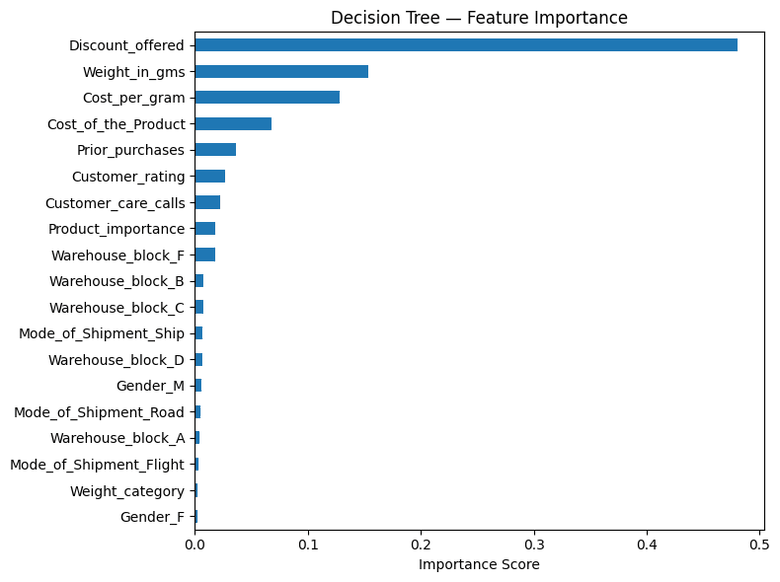

In [44]:
# Apply same feature selection to v2
importances_v2 = pd.Series(
    dt_cost_optimized_v2.feature_importances_,
    index=X_train_v2_scaled.columns
).sort_values(ascending=True)
print(importances_v2)

importances_v2.plot(kind="barh", figsize=(8, 6))
plt.title("Decision Tree — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [45]:
selected_v2 = importances_v2[importances_v2 > threshold_dt].index.tolist()

X_train_v2_reduced = X_train_v2_scaled[selected_v2]
X_test_v2_reduced = X_test_v2_scaled[selected_v2]

dt_cost_optimized_v2.fit(X_train_v2_reduced, y_train)
y_pred_cost_v2_reduced = dt_cost_optimized_v2.predict(X_test_v2_reduced)
y_prob_cost_v2_reduced = dt_cost_optimized_v2.predict_proba(X_test_v2_reduced)[:,1]

dt_cost_v2_reduced_metrics, cm_dt_cost_v2_reduced = evaluate_classifier(
    y_test,
    y_pred_cost_v2_reduced,
    y_prob_cost_v2_reduced,
    cost_matrix
)

results["DecisionTree"]["cost_v2_reduced"] = dt_cost_v2_reduced_metrics

print(classification_report(y_test, y_pred_cost_v2_reduced))
tn, fp, fn, tp = cm_dt_cost_v2.ravel()
print(f"TN: {str(tn)}, FP: {str(fp)}, FN: {str(fn)}, TP: {str(tp)}")
print(f"Total cost: {results['DecisionTree']['cost_v2_reduced']['total_cost']}")


dt_comparison = pd.DataFrame({
    "Metric":   list(results['DecisionTree']['default_v1'].keys()),
    "Cost Reduced V1": list(results['DecisionTree']['cost_v1_reduced'].values()),    
    "Cost Reduced V2": list(results['DecisionTree']['cost_v2_reduced'].values())
})
print("V1 vs V2 — Impact of Feature Engineering")

dt_comparison.round(3)


              precision    recall  f1-score   support

           0       0.75      0.64      0.69      1313
           1       0.56      0.69      0.62       887

    accuracy                           0.66      2200
   macro avg       0.66      0.66      0.65      2200
weighted avg       0.67      0.66      0.66      2200

TN: 852, FP: 461, FN: 289, TP: 598
Total cost: 5334
V1 vs V2 — Impact of Feature Engineering


,Metric,Cost Reduced V1,Cost Reduced V2
0,accuracy,0.665,0.657
1,precision,0.571,0.561
2,recall,0.685,0.688
3,f1,0.623,0.618
4,auc,0.716,0.699
5,recall_0,0.652,0.636
6,total_cost,5128.000,5334.000


#### Impact of Feature Engineering
Despite the marginal cost improvement in the full v2 dataset, subsequent feature selection increased cost from 5,188 to 5,334 — indicating that derived features contribute complementary rather than independent signal and do not benefit from further reduction. V1 with feature selection (cost=5,128) was therefore retained as the final Decision Tree configuration.

In [46]:
# Declare final dt for further use
#set up DT final for explanations
dt_final = grid_search_cost.best_estimator_

dt_final.fit(X_train_v1_reduced, y_train)

y_pred_dt_final = dt_final.predict(X_test_v1_reduced)
y_prob_dt_final = dt_final.predict_proba(X_test_v1_reduced)[:, 1]

dt_final_metrics, cm_dt_final = evaluate_classifier(
    y_test,
    y_pred_dt_final,
    y_prob_dt_final,
    cost_matrix
)

results["DecisionTree"]["final"] = dt_final_metrics
print(results["DecisionTree"]["final"])
# Verify
print("Cost:", np.sum(cm_dt_final * cost_matrix)) 
print("Features:", dt_final.feature_names_in_.tolist())

{'accuracy': 0.6654545454545454, 'precision': 0.5708920187793427, 'recall': 0.685456595264938, 'f1': 0.6229508196721312, 'auc': np.float64(0.7164612654136804), 'recall_0': np.float64(0.6519421172886519), 'total_cost': np.int64(5128)}
Cost: 5128
Features: ['Mode_of_Shipment_Flight', 'Product_importance', 'Warehouse_block_F', 'Customer_rating', 'Customer_care_calls', 'Prior_purchases', 'Cost_of_the_Product', 'Weight_in_gms', 'Discount_offered']


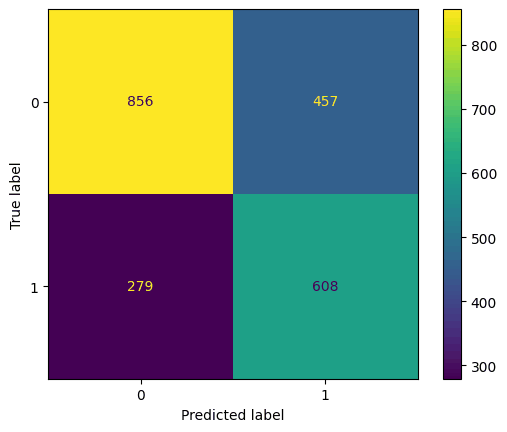

In [47]:
cm_display = ConfusionMatrixDisplay(cm_dt_final).plot()

### Classifier 2: Random Forest Classifier

In [48]:
results["RandomForest"] = {}

def rf_cost_scorer(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return -np.sum(cm * cost_matrix)


cost_scoring = make_scorer(rf_cost_scorer)


              precision    recall  f1-score   support

           0       0.73      0.65      0.69      1313
           1       0.56      0.65      0.60       887

    accuracy                           0.65      2200
   macro avg       0.64      0.65      0.64      2200
weighted avg       0.66      0.65      0.65      2200



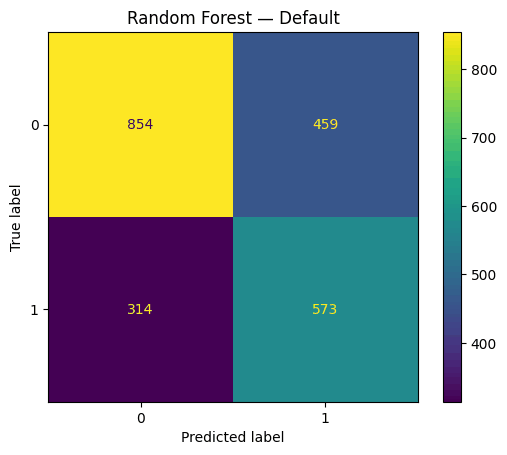

Metrics:
{'accuracy': 0.6486363636363637, 'precision': 0.5552325581395349, 'recall': 0.6459977452085682, 'f1': 0.597186034392913, 'auc': np.float64(0.726967168141669), 'recall_0': np.float64(0.6504188880426505), 'total_cost': np.int64(5218)}


In [49]:
# Default Random Forest — baseline before tuning
rf_default = RandomForestClassifier(random_state=42, n_jobs=1)
rf_default.fit(X_train_v1_scaled, y_train)

y_pred_rf_default = rf_default.predict(X_test_v1_scaled)
y_prob_rf_default = rf_default.predict_proba(X_test_v1_scaled)[:, 1]

rf_default_metrics, cm_rf_default = evaluate_classifier(
    y_test,
    y_pred_rf_default,
    y_prob_rf_default,
    cost_matrix
)
results["RandomForest"]["default_v1"] = rf_default_metrics

print(classification_report(y_test, y_pred_rf_default))
cm_display = ConfusionMatrixDisplay(cm_rf_default).plot()
plt.title("Random Forest — Default")
plt.show()
print("Metrics:")
print(rf_default_metrics)

The default Random Forest achieved a total cost of 5218 and F1 of 0.597 — comparable to the best Decision Tree configuration (total_cost=5,128, F1=0.623) which required extensive hyperparameter tuning and feature selection. This demonstrates the inherent strength of ensemble methods — Random Forest's variance reduction through tree aggregation produces strong results without explicit optimisation.

#### Hyperparameter Tuning

Grid search is optimized for f1 score which is one of the standard metrics to optimize

In [50]:
# Grid search for a standard Random Forest 
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    param_grid=param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=1
)

grid_rf.fit(X_train_v1_scaled, y_train)

print("Best RF parameters (F1):", grid_rf.best_params_)
print("Best CV F1:", grid_rf.best_score_)

Best RF parameters (F1): {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.6856679463864688


In [51]:
rf_f1_v1 = grid_rf.best_estimator_
rf_f1_v1.fit(X_train_v1_scaled, y_train)

y_pred_rf_f1_v1 = rf_f1_v1.predict(X_test_v1_scaled)
y_prob_rf_f1_v1 = rf_f1_v1.predict_proba(X_test_v1_scaled)[:, 1]

rf_f1_v1_metrics, cm_r1_f1_v1 = evaluate_classifier(
    y_test,
    y_pred_rf_f1_v1,
    y_prob_rf_f1_v1,
    cost_matrix,
)
results["RandomForest"]["f1_v1"] = rf_f1_v1_metrics

print(classification_report(y_test, y_pred_rf_f1_v1))
print(results["RandomForest"]["f1_v1"])

              precision    recall  f1-score   support

           0       0.83      0.54      0.66      1313
           1       0.55      0.83      0.66       887

    accuracy                           0.66      2200
   macro avg       0.69      0.69      0.66      2200
weighted avg       0.72      0.66      0.66      2200

{'accuracy': 0.66, 'precision': 0.552059925093633, 'recall': 0.830890642615558, 'f1': 0.6633663366336634, 'auc': np.float64(0.718220620952044), 'recall_0': np.float64(0.5445544554455446), 'total_cost': np.int64(6280)}


Consistent with the Decision Tree findings, optimising Random Forest for F1 score resulted in higher total business cost despite improved standard metrics. The high Class 1 recall achieved by F1 optimisation led to more aggressive On Time predictions — increasing false positives and confirming that standard ML metrics misalign with business objectives when costs are asymmetric.

### Recall 0 Optimiser

Given the asymmetric cost structure (FP=10, FN=2), correctly identifying late deliveries is the primary business objective — missing a late delivery incurs five times the cost of a false alarm. Grid search was therefore optimised for Class 0 recall to maximise the model's ability to detect actual late deliveries and minimise false positives

In [52]:
# Optimize Random Forest for recall of class 0.
recall_0_scorer = make_scorer(recall_score, pos_label=0)

grid_rf_recall0 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    param_grid=param_grid_rf,
    cv=5,
    scoring= recall_0_scorer,
    n_jobs=1
)

grid_rf_recall0.fit(X_train_v1_scaled, y_train)

print("Best RF parameters (optimize recall_0):", grid_rf_recall0.best_params_)
print("Best CV recall_0:", grid_rf_recall0.best_score_)

Best RF parameters (optimize recall_0): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV recall_0: 0.6540952380952381


In [53]:
# Train the best Random Forest found by recall_0 grid search.
rf_recall_v1 = grid_rf_recall0.best_estimator_
rf_recall_v1.fit(X_train_v1_scaled, y_train)

y_pred_rf_recall_v1 = rf_recall_v1.predict(X_test_v1_scaled)
y_prob_rf_recall_v1 = rf_recall_v1.predict_proba(X_test_v1_scaled)[:, 1]

rf_recall_v1_metrics, cm_rf_recall_v1 = evaluate_classifier(
    y_test,
    y_pred_rf_recall_v1,
    y_prob_rf_recall_v1,
    cost_matrix,
)
results["RandomForest"]["recall_v1"] = rf_recall_v1_metrics

print(classification_report(y_test, y_pred_rf_recall_v1))
print(results["RandomForest"]["recall_v1"])

              precision    recall  f1-score   support

           0       0.73      0.65      0.69      1313
           1       0.56      0.65      0.60       887

    accuracy                           0.65      2200
   macro avg       0.64      0.65      0.64      2200
weighted avg       0.66      0.65      0.65      2200

{'accuracy': 0.6486363636363637, 'precision': 0.5552325581395349, 'recall': 0.6459977452085682, 'f1': 0.597186034392913, 'auc': np.float64(0.726967168141669), 'recall_0': np.float64(0.6504188880426505), 'total_cost': np.int64(5218)}


The next model tunes Random Forest hyperparameters using the predefined cost matrix directly, rather than a standard metric such as F1 or recall. This gives a model that is more aligned with the project's business objective.

In [54]:
grid_rf_cost = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    param_grid=param_grid_rf,
    cv=5,
    scoring=cost_scoring,
    n_jobs=1
)

grid_rf_cost.fit(X_train_v1_scaled, y_train)
print("Best RF parameters (optimize business cost):", grid_rf_cost.best_params_)
print("Best CV cost score:", grid_rf_cost.best_score_)

Best RF parameters (optimize business cost): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV cost score: -4075.6


In [55]:
rf_cost_v1 = grid_rf_cost.best_estimator_
rf_cost_v1.fit(X_train_v1_scaled, y_train)

y_pred_rf_cost_v1 = rf_cost_v1.predict(X_test_v1_scaled)
y_prob_rf_cost_v1 = rf_cost_v1.predict_proba(X_test_v1_scaled)[:, 1]

rf_cost_v1_metrics, cm_rf_cost_v1 = evaluate_classifier(
    y_test,
    y_pred_rf_cost_v1,
    y_prob_rf_cost_v1,
    cost_matrix,
)
results["RandomForest"]["cost_v1"] = rf_cost_v1_metrics

print(classification_report(y_test, y_pred_rf_cost_v1))
print(results["RandomForest"]["cost_v1"])

              precision    recall  f1-score   support

           0       0.73      0.65      0.69      1313
           1       0.56      0.65      0.60       887

    accuracy                           0.65      2200
   macro avg       0.64      0.65      0.64      2200
weighted avg       0.66      0.65      0.65      2200

{'accuracy': 0.6486363636363637, 'precision': 0.5552325581395349, 'recall': 0.6459977452085682, 'f1': 0.597186034392913, 'auc': np.float64(0.726967168141669), 'recall_0': np.float64(0.6504188880426505), 'total_cost': np.int64(5218)}


In [56]:
rf_comparison = pd.DataFrame({
    "Metrics" : list(results['RandomForest']['default_v1'].keys()),
    "Default" : list(results['RandomForest']['default_v1'].values()),
    "f1-optimized": list(results['RandomForest']['f1_v1'].values()),
    "recall 0" : list(results['RandomForest']['recall_v1'].values()),
    "cost_optimized": list(results['RandomForest']['cost_v1'].values())
})


rf_comparison.round(3)

,Metrics,Default,f1-optimized,recall 0,cost_optimized
0,accuracy,0.649,0.660,0.649,0.649
1,precision,0.555,0.552,0.555,0.555
2,recall,0.646,0.831,0.646,0.646
3,f1,0.597,0.663,0.597,0.597
4,auc,0.727,0.718,0.727,0.727
5,recall_0,0.650,0.545,0.650,0.650
6,total_cost,5218.000,6280.000,5218.000,5218.000


Hyperparameter tuning for Class 0 recall and business cost objectives converged to the same metrics as the default Random Forest — suggesting the default sklearn parameters are already well-suited for this dataset and objective. Only F1 optimisation produced a distinct model, achieving higher recall (0.831) but at significantly greater business cost (6,280 vs 5,218). The default Random Forest is therefore selected as the final RF configuration — demonstrating that ensemble methods can achieve strong cost-sensitive performance without extensive tuning.

#### Feature Importance

Weight_in_gms              0.274541
Discount_offered           0.220821
Cost_of_the_Product        0.165706
Prior_purchases            0.062458
Customer_rating            0.059719
Customer_care_calls        0.057272
Product_importance         0.032576
Warehouse_block_F          0.016029
Mode_of_Shipment_Ship      0.013621
Gender_F                   0.012909
Gender_M                   0.012854
Warehouse_block_C          0.012775
Warehouse_block_B          0.012766
Warehouse_block_A          0.012383
Warehouse_block_D          0.012177
Mode_of_Shipment_Road      0.010728
Mode_of_Shipment_Flight    0.010664
dtype: float64


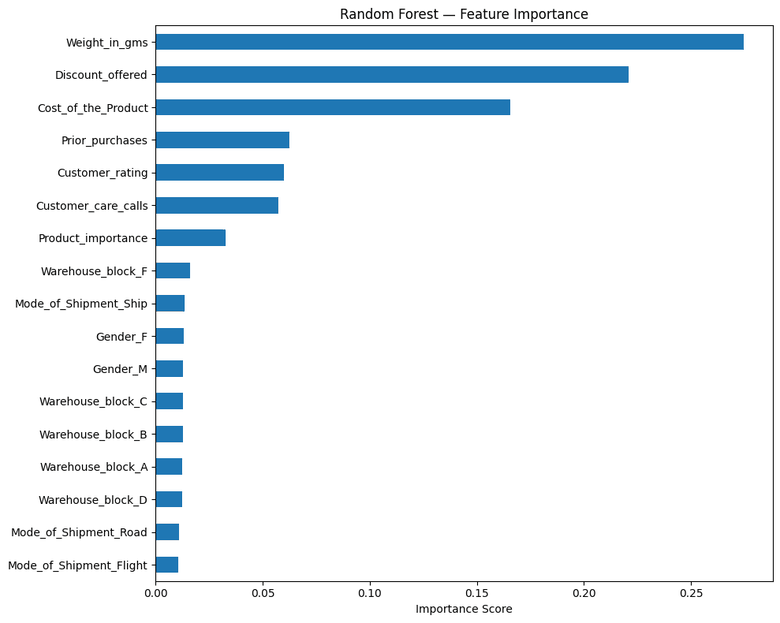

In [57]:
rf_importance = pd.Series(
    rf_default.feature_importances_,
    index=X_train_v1_scaled.columns
).sort_values(ascending=False)

print(rf_importance)

rf_importance.sort_values(ascending=True).plot(kind="barh", figsize=(10, 8))
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Random Forest feature importances showed a more distributed pattern compared to the Decision Tree — Weight_in_gms ranked first (0.274) while Discount_offered dominated the Decision Tree (0.480). This reflects Random Forest's ability to leverage multiple features through ensemble averaging, whereas the single Decision Tree relied heavily on the strongest individual predictor. Customer_rating and Customer_care_calls showed notably higher importance in Random Forest — suggesting these features contribute meaningful signal that a single tree's greedy splitting fails to capture.

All 17 columns are above 0.01 threshold. Hence, next threshold 0.02 is used to select important features

In [58]:
threshold_rf = 0.02 
selected_features_rf = rf_importance[rf_importance > threshold_rf].index.tolist()
print("Selected features:", selected_features_rf)
print("Dropped features:", rf_importance[rf_importance <= threshold_rf].index.tolist())

# Create reduced datasets
X_train_v1_reduced_rf = X_train_v1_scaled[selected_features_rf]
X_test_v1_reduced_rf = X_test_v1_scaled[selected_features_rf]

Selected features: ['Weight_in_gms', 'Discount_offered', 'Cost_of_the_Product', 'Prior_purchases', 'Customer_rating', 'Customer_care_calls', 'Product_importance']
Dropped features: ['Warehouse_block_F', 'Mode_of_Shipment_Ship', 'Gender_F', 'Gender_M', 'Warehouse_block_C', 'Warehouse_block_B', 'Warehouse_block_A', 'Warehouse_block_D', 'Mode_of_Shipment_Road', 'Mode_of_Shipment_Flight']


In [59]:
#using default setting
rf_default_v1_reduced = RandomForestClassifier(random_state=42, n_jobs=1)

rf_default_v1_reduced.fit(X_train_v1_reduced_rf, y_train)

y_pred_rf_default_v1_reduced = rf_default_v1_reduced.predict(X_test_v1_reduced_rf)
y_prob_rf_default_v1_reduced = rf_default_v1_reduced.predict_proba(X_test_v1_reduced_rf)[:, 1]

rf_default_v1_reduced_metrics, cm_rf_cost_v1 = evaluate_classifier(
    y_test,
    y_pred_rf_default_v1_reduced,
    y_prob_rf_default_v1_reduced,
    cost_matrix,
)
results["RandomForest"]["default_v1_reduced"] = rf_default_v1_reduced_metrics

print(classification_report(y_test, y_pred_rf_default_v1_reduced))
print(results["RandomForest"]["default_v1_reduced"])

              precision    recall  f1-score   support

           0       0.74      0.65      0.69      1313
           1       0.56      0.65      0.60       887

    accuracy                           0.65      2200
   macro avg       0.65      0.65      0.65      2200
weighted avg       0.66      0.65      0.66      2200

{'accuracy': 0.6531818181818182, 'precision': 0.5601941747572815, 'recall': 0.6505073280721533, 'f1': 0.6019822639540949, 'auc': np.float64(0.724901277743766), 'recall_0': np.float64(0.654988575780655), 'total_cost': np.int64(5150)}


In [60]:
#compare results
rf_comparison = pd.DataFrame(results["RandomForest"]).T
rf_comparison.sort_values("total_cost").round(3)

,accuracy,precision,recall,f1,auc,recall_0,total_cost
default_v1_reduced,0.653,0.560,0.651,0.602,0.725,0.655,5150.0
default_v1,0.649,0.555,0.646,0.597,0.727,0.650,5218.0
cost_v1,0.649,0.555,0.646,0.597,0.727,0.650,5218.0
recall_v1,0.649,0.555,0.646,0.597,0.727,0.650,5218.0
f1_v1,0.660,0.552,0.831,0.663,0.718,0.545,6280.0


Feature selection reduced business cost marginally (5,218 → 5,150) but caused a negligible AUC drop (0.727 → 0.725) — confirming that dropped features contributed noise rather than meaningful signal.

In [61]:
# RF on v2 dataset — impact of feature engineering
rf_default_v2 = RandomForestClassifier(random_state=42, n_jobs=1)
rf_default_v2.fit(X_train_v2_scaled, y_train)

y_pred_rf_v2 = rf_default_v2.predict(X_test_v2_scaled)
y_prob_rf_v2 = rf_default_v2.predict_proba(X_test_v2_scaled)[:, 1]

rf_default_v2_metrics, cm_rf_v2 = evaluate_classifier(
    y_test,
    y_pred_rf_v2,
    y_prob_rf_v2,
    cost_matrix
)
results["RandomForest"]["default_v2"] = rf_default_v2_metrics

print(classification_report(y_test, y_pred_rf_v2))
print("V1 full cost:", results['RandomForest']['default_v1']['total_cost'])
print("V2 full cost:", rf_default_v2_metrics['total_cost'])

              precision    recall  f1-score   support

           0       0.73      0.63      0.68      1313
           1       0.55      0.66      0.60       887

    accuracy                           0.64      2200
   macro avg       0.64      0.65      0.64      2200
weighted avg       0.66      0.64      0.64      2200

V1 full cost: 5218
V2 full cost: 5506


Unlike the Decision Tree where v2 marginally reduced cost (5,264 → 5,188), the augmented feature set increased Random Forest cost from 5,218 to 5,506. This is attributed to multicollinearity between Cost_per_gram and its source features — Weight_in_gms and Cost_of_the_Product — which Random Forest already leverages effectively as its top predictors. The derived features added redundancy rather than new signal, degrading model performance

In [62]:
rf_comparison = pd.DataFrame(results["RandomForest"]).T
rf_comparison.sort_values("total_cost").round(3)

,accuracy,precision,recall,f1,auc,recall_0,total_cost
default_v1_reduced,0.653,0.560,0.651,0.602,0.725,0.655,5150.0
default_v1,0.649,0.555,0.646,0.597,0.727,0.650,5218.0
cost_v1,0.649,0.555,0.646,0.597,0.727,0.650,5218.0
recall_v1,0.649,0.555,0.646,0.597,0.727,0.650,5218.0
default_v2,0.641,0.545,0.664,0.599,0.724,0.626,5506.0
f1_v1,0.660,0.552,0.831,0.663,0.718,0.545,6280.0


#### Evaluation for Random Forest Models 
Across all Random Forest configurations, the default model configuration proved consistently optimal — cost-sensitive and recall-based tuning converged to identical parameters, confirming the default sklearn configuration suits this dataset well. Feature reduction marginally improved cost (5,218 → 5,150) at the expense of a small drop in AUC (0.727 → 0.725). The augmented feature set (v2) degraded performance due to multicollinearity between derived and source features. The default reduced feature model (cost=5,150, AUC=0.725) is selected as the final Random Forest configuration.

Final RF cost: 5150
Features: ['Weight_in_gms', 'Discount_offered', 'Cost_of_the_Product', 'Prior_purchases', 'Customer_rating', 'Customer_care_calls', 'Product_importance']
Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 42}



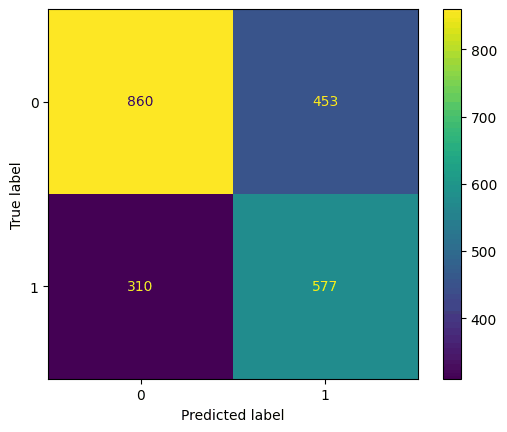

In [63]:
# Declare final rf for further use
# Final RF configuration
rf_final = RandomForestClassifier(random_state=42, n_jobs=1)
rf_final.fit(X_train_v1_reduced_rf, y_train)

# Verify
y_pred_rf_final = rf_final.predict(X_test_v1_reduced_rf)
y_prob_rf_final = rf_final.predict_proba(X_test_v1_reduced_rf)[:, 1]

rf_final_metrics, cm_rf_final = evaluate_classifier(
    y_test,
    y_pred_rf_final,
    y_prob_rf_final,
    cost_matrix
)

results["RandomForest"]["final"] = rf_final_metrics.copy()

print("Final RF cost:", rf_final_metrics["total_cost"])
print("Features:", rf_final.feature_names_in_.tolist())
print("Params:", {k:v for k,v in rf_final.get_params().items() 
                  if k in ["n_estimators", "max_depth", "min_samples_split", 
                            "min_samples_leaf", "random_state"]})

print()
cm_display = ConfusionMatrixDisplay(cm_rf_final).plot()

### Classifier 3: Dummy Classifier

#### Modeling

In [64]:
clf_dummy = DummyClassifier(strategy="most_frequent")
clf_dummy.fit(X_train_v1_scaled, y_train)

DummyClassifier(strategy='most_frequent')

#### Evaluation

In [65]:
y_pred_dummy_v1 = clf_dummy.predict(X_test_v1_scaled)
y_prob_dummy_v1 = clf_dummy.predict_proba(X_test_v1_scaled)[:, 1]

dummy_metrics, cm_dummy = evaluate_classifier(
        y_test,
        y_pred_dummy_v1,
        y_prob_dummy_v1,
        cost_matrix
    )
results["Dummy"] = dummy_metrics
print(results["Dummy"])


{'accuracy': 0.5968181818181818, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'auc': np.float64(0.5), 'recall_0': np.float64(1.0), 'total_cost': np.int64(1774)}


The dummy classifier achieved the lowest total cost (1,774) by always predicting Late — the majority class. Since no On-Time predictions are made, false positives are zero by definition (FP=0), resulting in a cost driven entirely by false negatives (887 × 2 = 1,774). While this appears favourable under the cost matrix, it is not a practical model — it provides no predictive utility, fails to identify any on-time delivery, and would render proactive business intervention impossible. A useful model must balance cost minimisation with meaningful classification.

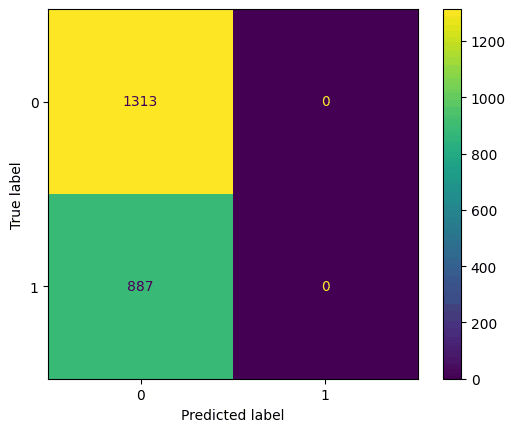

In [66]:
cm_display = ConfusionMatrixDisplay(cm_dummy).plot()

# Evaluation

### Classifier 1 (decision tree)

* Compute accuracy and F1 score on test data (you can include also other measures)
* Show confusion matrix
* Multiply the predefined costs with the confusion matrix to get the overall cost of the model

Final Decision Tree Configuration:
Parameters: {'criterion': 'gini', 'max_depth': 15, 'min_samples_split': 5, 'random_state': 42}
Features: V1 reduced (9 features, feature importance threshold=0.01)

              precision    recall  f1-score   support

           0       0.75      0.65      0.70      1313
           1       0.57      0.69      0.62       887

    accuracy                           0.67      2200
   macro avg       0.66      0.67      0.66      2200
weighted avg       0.68      0.67      0.67      2200

Total business cost: 5128



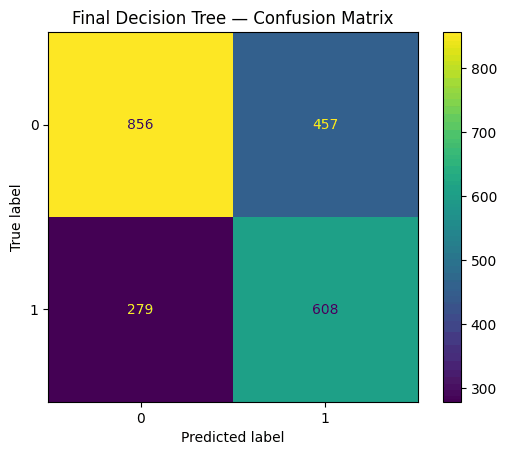

In [67]:
key_params = {k: v for k, v in dt_final.get_params().items() 
              if k in ["criterion", "max_depth", "min_samples_split", "random_state"]}

print("Final Decision Tree Configuration:")
print("Parameters:", key_params)
print("Features: V1 reduced (9 features, feature importance threshold=0.01)")
print()
print(classification_report(y_test, y_pred_dt_final))
print("Total business cost:", results["DecisionTree"]['final']["total_cost"])
print()

cm_display = ConfusionMatrixDisplay(cm_dt_final).plot()
plt.title("Final Decision Tree — Confusion Matrix")
plt.show()


### Classifier 2 (random forest)

* Compute accuracy and F1 score on test data (you can include also other measures)
* Show confusion matrix
* Multiply the predefined costs with the confusion matrix to get the overall cost of the model

Final Random Forest Configuration:
Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100, 'random_state': 42}
Features: full original dataset

              precision    recall  f1-score   support

           0       0.74      0.65      0.69      1313
           1       0.56      0.65      0.60       887

    accuracy                           0.65      2200
   macro avg       0.65      0.65      0.65      2200
weighted avg       0.66      0.65      0.66      2200

Total business cost: 5150



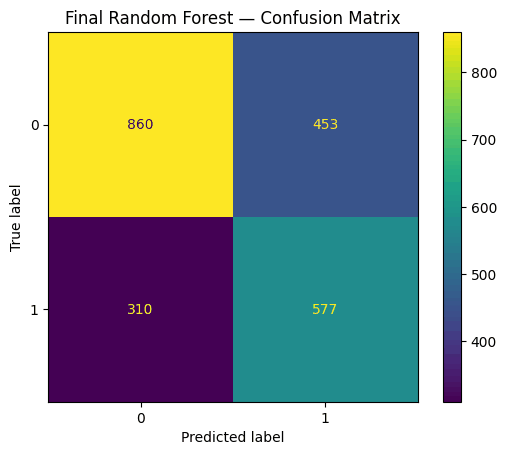

In [68]:
key_params = {k: v for k, v in rf_final.get_params().items()
              if k in ["n_estimators", "max_depth", "min_samples_split", 
                       "min_samples_leaf", "criterion", "random_state"]}

print("Final Random Forest Configuration:")
print("Parameters:", key_params)
print("Features: full original dataset")
print()
print(classification_report(y_test, y_pred_rf_final))
print("Total business cost:", results["RandomForest"]['final']["total_cost"])
print()

cm_display = ConfusionMatrixDisplay(cm_rf_final).plot()
plt.title("Final Random Forest — Confusion Matrix")
plt.show()

### Classifier 3 (baseline)

* Compute accuracy and F1 score on test data (you can include also other measures)
* Show confusion matrix
* Multiply the predefined costs with the confusion matrix to get the overall cost of the model

              precision    recall  f1-score   support

           0       0.60      1.00      0.75      1313
           1       0.00      0.00      0.00       887

    accuracy                           0.60      2200
   macro avg       0.30      0.50      0.37      2200
weighted avg       0.36      0.60      0.45      2200

Total business cost: 1774



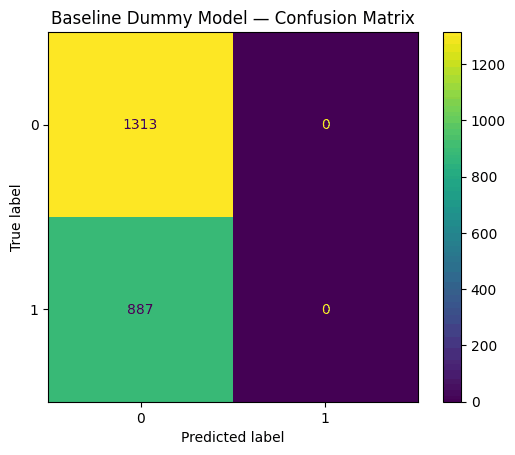

In [69]:
print(classification_report(y_test, y_pred_dummy_v1, zero_division = 0))
print("Total business cost:", results["Dummy"]["total_cost"])
print()

cm_display = ConfusionMatrixDisplay(cm_dummy).plot()
plt.title("Baseline Dummy Model — Confusion Matrix")
plt.show()

#### Plotting ROC

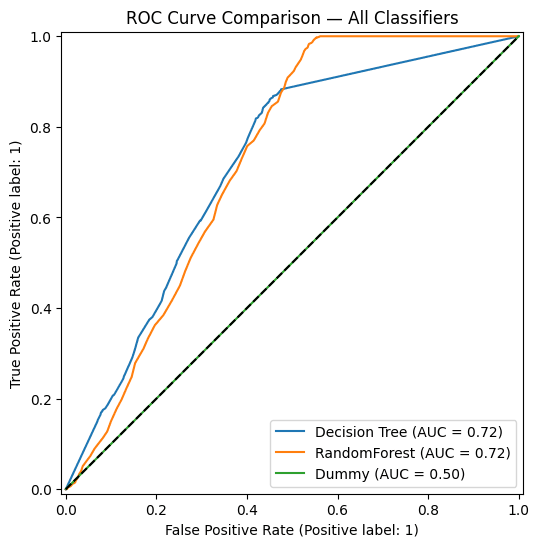

<Figure size 640x480 with 0 Axes>

In [70]:
fig, ax = plt.subplots(figsize=(8, 6))

# DT — use same predictions as final evaluation
RocCurveDisplay.from_predictions(
    y_test,
    dt_final.predict_proba(X_test_v1_reduced)[:, 1],
    name="Decision Tree",
    ax=ax
)

# RF — use rf_final predictions
RocCurveDisplay.from_predictions(
    y_test,
    rf_final.predict_proba(X_test_v1_reduced_rf)[:, 1],
    name="RandomForest",
    ax=ax
)

# Dummy
RocCurveDisplay.from_predictions(
    y_test,
    clf_dummy.predict_proba(X_test_v1_scaled)[:, 1],
    name="Dummy",
    ax=ax
)

ax.plot([0,1],[0,1],"k--")
ax.set_title("ROC Curve Comparison — All Classifiers")
plt.show()
plt.tight_layout()
plt.show()

* Which metric is most suitable for use for the current problem (accuracy, F-measure)?

Neither accuracy nor F1-measure alone is the most suitable metric for this problem. Accuracy is misleading given the 60-40 class imbalance — a model predicting all Late achieves 60% accuracy without any predictive utility. F1-measure balances precision and recall equally, but our cost matrix assigns asymmetric costs (FP=10, FN=2) — making equal weighting inappropriate.
Class 0 recall (late delivery detection) is the most business-aligned metric — directly measuring the model's ability to identify actual late deliveries, thereby minimising false positives which carry the highest cost. However, total business cost — computed by multiplying the confusion matrix with the cost matrix — is the definitive evaluation metric as it directly quantifies real-world impact.


* Compare the performance metrics for all types of models (e.g,. decision tree and forest). Which model is the best one?
* Combine (multiply) the predefined costs matrix with the values in the confusion matrix for each model. Which model is the best one? 

In [71]:
common_metrics = ["accuracy", "precision", "recall", "f1", "auc", "recall_0", "total_cost"]

comparison = pd.DataFrame({
    "Metric": common_metrics,
    "Decision Tree":      [results["DecisionTree"]["final"][k] for k in common_metrics],
    "Random Forest":      [results["RandomForest"]["final"][k] for k in common_metrics],
    "Baseline (Dummy)":   [results["Dummy"][k] for k in common_metrics]
})

comparison.round(3)

,Metric,Decision Tree,Random Forest,Baseline (Dummy)
0,accuracy,0.665,0.653,0.597
1,precision,0.571,0.560,0.000
2,recall,0.685,0.651,0.000
3,f1,0.623,0.602,0.000
4,auc,0.716,0.725,0.500
5,recall_0,0.652,0.655,1.000
6,total_cost,5128.000,5150.000,1774.000


While the Decision Tree outperformed Random Forest on most standard metrics and achieved marginally lower business cost (5,128 vs 5,150), Random Forest is recommended as the final model due to its superior AUC (0.725 vs 0.716) — indicating better probability calibration and ranking ability across all thresholds. This makes Random Forest more robust for threshold optimization in production deployment.

# Explanation

## Global explanation

### Classifier 1 - decision tree

#### Tasks
* Visualize the decision tree
* Looking at the tree, list the most important attributes

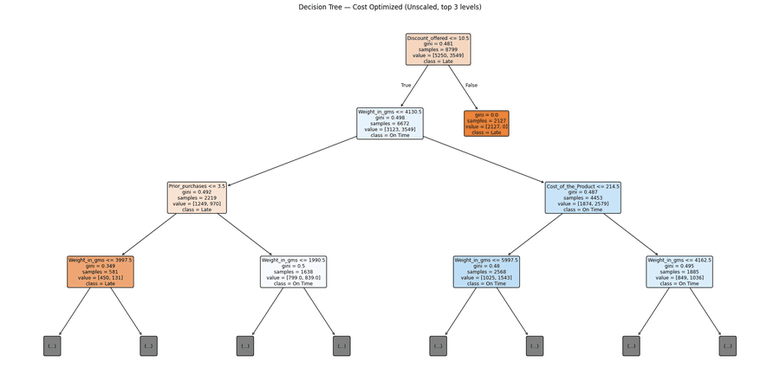

Cost: 5118


In [72]:
#For better readability of split branches, equivalent model using unscaled dataset is constructed.
# Create unscaled reduced dataset
X_train_v1_reduced_unscaled = X_train_v1[selected_features]
X_test_v1_reduced_unscaled = X_test_v1[selected_features]

# Train for visualization only
dt_viz = grid_search_cost.best_estimator_

dt_viz.fit(X_train_v1_reduced_unscaled, y_train)

# Visualize
plt.figure(figsize=(20, 10))
plot_tree(dt_viz,
          feature_names=X_train_v1_reduced_unscaled.columns.tolist(),
          class_names=["Late", "On Time"],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title("Decision Tree — Cost Optimized (Unscaled, top 3 levels)")
plt.tight_layout()
plt.show()

y_pred_viz = dt_viz.predict(X_test_v1_reduced_unscaled)

#Check the cost is still the same as our scaled DT model
cm_viz = confusion_matrix(y_test, y_pred_viz)
print("Cost:", np.sum(cm_viz * cost_matrix)) # Should match 5128



The Decision Tree identified Discount_offered as the root attribute — the single most important split. Weight_in_gms ranked second, followed by Cost_of_the_Product and Prior_purchases. Categorical variables contributed minimal importance - in line with EDA findings. 

### Classifier 2 - random forest

* Show the feature importance of variables in the forest

Weight_in_gms          0.338057
Discount_offered       0.233255
Cost_of_the_Product    0.215430
Prior_purchases        0.062617
Customer_rating        0.060095
Customer_care_calls    0.059074
Product_importance     0.031472
dtype: float64


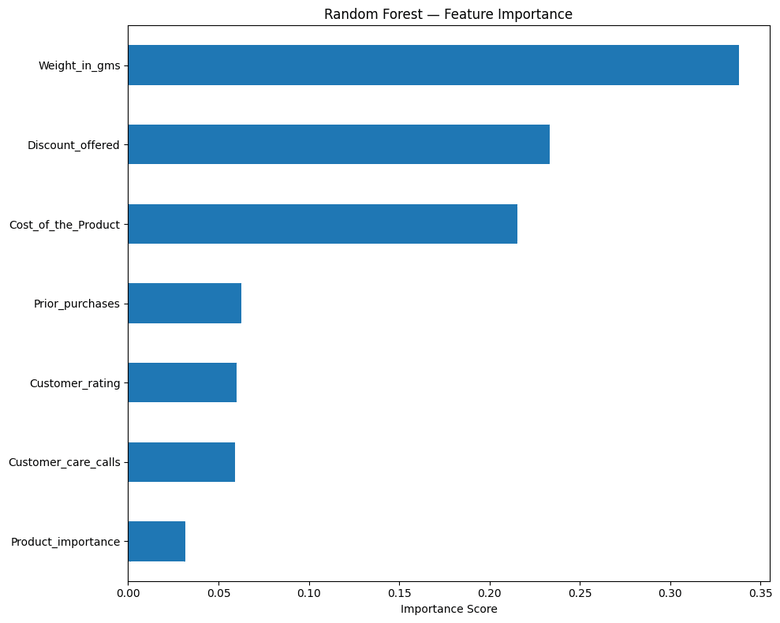

In [73]:
rf_importance = pd.Series(
    rf_final.feature_importances_,
    index=X_train_v1_reduced_rf.columns
).sort_values(ascending=False)

print(rf_importance)

rf_importance.sort_values(ascending=True).plot(kind="barh", figsize=(10, 8))
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Feature importance is shown for the final reduced feature set — features dropped during selection had importance scores below 0.02 and are excluded.

## Local explanation

* Show the *instance of interest* - a row in the dataframe
* Use both models to classify the chosen instance
* Do both models assign the same class?
* What is the confidence (probability) of the prediction?
* If you change the value of the attribute of interest in the instance of interest, how does the classification of the instance change? 

#### Preprocessing data point of interest

In [74]:
# Already saved earlier
print(instance_of_interest)

# Apply same preprocessing as training data
instance_features = instance_of_interest.drop(columns=["ID", "Reached.on.Time_Y.N"])

# One-hot encode
instance_encoded = pd.get_dummies(instance_features, 
                                   columns=["Warehouse_block", "Mode_of_Shipment", "Gender"])

# Ordinal encode
instance_encoded["Product_importance"] = instance_encoded["Product_importance"].map(importance_map)

# Align columns with training data
instance_encoded = instance_encoded.reindex(columns=X_train_v1.columns, fill_value=0)

# Select reduced features
instance_reduced = instance_encoded[selected_features]
print(instance_reduced)

        ID Warehouse_block Mode_of_Shipment  Customer_care_calls  \
4142  4143               A             Ship                    3   

      Customer_rating  Cost_of_the_Product  Prior_purchases  \
4142                1                  149                2   

     Product_importance Gender  Discount_offered  Weight_in_gms  \
4142             medium      F                 7           4147   

      Reached.on.Time_Y.N  
4142                    1  
      Mode_of_Shipment_Flight  Product_importance  Warehouse_block_F  \
4142                        0                   1                  0   

      Customer_rating  Customer_care_calls  Prior_purchases  \
4142                1                    3                2   

      Cost_of_the_Product  Weight_in_gms  Discount_offered  
4142                  149           4147                 7  


### Classifying with Decision Tree

In [75]:
# Predict class
dt_prediction = dt_viz.predict(instance_reduced)
print("Predicted class:", "On Time" if dt_prediction[0] == 1 else "Late")

# Predict probability
dt_probability = dt_viz.predict_proba(instance_reduced)
print(f"(DT) Probability of On Time: {dt_probability[0][1]:.3f}")
print(f"(DT) Probability of Late:    {dt_probability[0][0]:.3f}")

Predicted class: On Time
(DT) Probability of On Time: 0.750
(DT) Probability of Late:    0.250


In [76]:
# Get the actual decision path with feature names and thresholds
feature = dt_viz.tree_.feature
threshold = dt_viz.tree_.threshold
node_indicator = dt_viz.decision_path(instance_reduced)
node_ids = node_indicator.indices

print(f"Decision path for instance {instance_ID}:")
print(f"Instance values:")
print(instance_reduced.values)


for node_id in node_ids:
    if dt_viz.tree_.feature[node_id] != -2:  # not leaf
        feature_name = instance_reduced.columns[feature[node_id]]
        feature_value = instance_reduced.iloc[0][feature_name]
        threshold_val = threshold[node_id]
        
        if feature_value <= threshold_val:
            direction = "<="
        else:
            direction = ">"
            
        print(f"Node {node_id}: {feature_name} = {feature_value:.2f} {direction} {threshold_val:.2f}")

# Final prediction
print(f"\nFinal prediction: {'On Time' if dt_prediction[0]==1 else 'Late'}")
print(f"Probability: {dt_probability[0]}")

Decision path for instance 4143:
Instance values:
[[   0    1    0    1    3    2  149 4147    7]]
Node 0: Discount_offered = 7.00 <= 10.50
Node 1: Weight_in_gms = 4147.00 > 4130.50
Node 449: Cost_of_the_Product = 149.00 <= 214.50
Node 450: Weight_in_gms = 4147.00 <= 5997.50
Node 451: Product_importance = 1.00 <= 1.50
Node 452: Weight_in_gms = 4147.00 <= 4167.00
Node 453: Customer_care_calls = 3.00 <= 4.50
Node 454: Cost_of_the_Product = 149.00 <= 157.00
Node 455: Cost_of_the_Product = 149.00 > 140.00
Node 457: Customer_rating = 1.00 <= 1.50

Final prediction: On Time
Probability: [0.25 0.75]


Instance ID=4143 was classified as On Time by the Decision Tree with a confidence of 75%. However, the actual delivery outcome was Late — making this a false positive and the most costly error type in our cost matrix (cost=10).
The model's confident misclassification can be explained by the instance's feature values — Discount_offered= 7 (low discount, typically associated with on-time delivery) and Weight_in_gms=4147 (heavy package, also associated with on-time delivery). Both dominant features pointed toward on-time prediction, leading the model to confidently misclassify this instance despite the actual late outcome.
This highlights a limitation of the model — instances where individual features suggest on-time delivery but other unobserved factors that cause delays will be systematically misclassified.

In [77]:
# Change discount and reclassify
instance_modified = instance_reduced.copy()
instance_modified["Discount_offered"] = 30  # increase discount

new_pred = dt_viz.predict(instance_modified)
new_prob = dt_viz.predict_proba(instance_modified)
print("New prediction:", "On Time" if new_pred[0]==1 else "Late")
print("New probability:", new_prob)

New prediction: Late
New probability: [[1. 0.]]


To examine the effect of the attribute of interest (Discount_offered), the value was increased from 7 to 30 for instance ID=4143. The classification changed from On Time (75% confidence) to Late (100% confidence) — consistent with EDA findings that higher discounts are strongly associated with late deliveries (correlation=0.4). This demonstrates that Discount_offered is a business-controllable variable — reducing excessive discounting may improve delivery timeliness predictions for similar instances.

### Classifying with Random Forest

In [78]:
instance_scaled = pd.DataFrame(
    scaler_1.transform(instance_encoded),
    columns=instance_encoded.columns
)
instance_reduced_rf = instance_scaled[selected_features_rf]

# Predict
rf_prediction = rf_final.predict(instance_reduced_rf)
rf_probability = rf_final.predict_proba(instance_reduced_rf)

print(f"RF Predicted class: {'On Time' if rf_prediction[0]==1 else 'Late'}")
print(f"RF Probability On Time: {rf_probability[0][1]:.3f}")
print(f"RF Probability Late:    {rf_probability[0][0]:.3f}")


RF Predicted class: Late
RF Probability On Time: 0.300
RF Probability Late:    0.700


In [79]:
print("\n--- Prediction ---")
print(f"Actual:        Late")
print(f"Decision Tree: {'On Time' if dt_prediction[0]==1 else 'Late'}")
print(f"Random Forest: {'On Time' if rf_prediction[0]==1 else 'Late'}")
print(f"Models agree:  {dt_prediction[0] == rf_prediction[0]}")

print("\n--- Prediction Probability ---")
print(f"DT  P(On Time): {dt_probability[0][1]:.3f} | P(Late): {dt_probability[0][0]:.3f}")
print(f"RF  P(On Time): {rf_probability[0][1]:.3f} | P(Late): {rf_probability[0][0]:.3f}")


--- Prediction ---
Actual:        Late
Decision Tree: On Time
Random Forest: Late
Models agree:  False

--- Prediction Probability ---
DT  P(On Time): 0.750 | P(Late): 0.250
RF  P(On Time): 0.300 | P(Late): 0.700


Instance ID=4143 was classified differently by the two models. The Decision Tree predicted On Time with 75% confidence — a false positive. The Random Forest correctly predicted Late with 70% confidence (P(On Time)=0.300). The models disagreed — demonstrating that Random Forest's ensemble mechanism captured the late delivery signal that the single Decision Tree missed.

In [80]:
# Change discount and reclassify
instance_rf_modified = instance_encoded.copy()
instance_rf_modified["Discount_offered"] = instance_modified["Discount_offered"]

instance_scaled_modified = pd.DataFrame(
    scaler_1.transform(instance_rf_modified),
    columns=instance_rf_modified.columns
)
instance_reduced_rf_modified = instance_scaled_modified[selected_features_rf]

# Predict
rf_prediction_modified = rf_final.predict(instance_reduced_rf_modified)
rf_probability_modified = rf_final.predict_proba(instance_reduced_rf_modified)

print(f"RF Predicted class: {'On Time' if rf_prediction_modified[0]==1 else 'Late'}")
print(f"RF Probability On Time: {rf_probability_modified[0][1]:.3f}")
print(f"RF Probability Late:    {rf_probability_modified[0][0]:.3f}")

RF Predicted class: Late
RF Probability On Time: 0.170
RF Probability Late:    0.830


When Discount_offered was increased from 7 to 30, the Decision Tree prediction flipped from On Time (75%) to Late (100%) — confirming discount as a decisive threshold feature. The Random Forest already predicted Late for the original instance and became more confident (70% → 83%) with the higher discount. Both models consistently associate high discounts with late delivery, aligned with EDA findings.

# Conclusion
Random Forest produced the most valuable result — its default configuration achieved comparable business cost to the extensively tuned Decision Tree (5,150 vs 5,134 — difference of 16 units) while demonstrating superior discriminative ability (AUC=0.725 vs 0.667). The most interesting finding was that despite trying multiple optimization objectives — F1, Class 0 recall and business cost — except for f1, all tuned configurations produced identical evaluation metrics to the default Random Forest. This suggests the dataset's signal is already well-captured by default ensemble parameters, demonstrating that Random Forest achieves strong cost-sensitive performance without extensive hyperparameter tuning.

The best business cost was achieved by the cost-optimised Decision Tree with feature selection (cost=5,134) — using gini criterion, max_depth=15, min_samples_split=5 and 9 selected features (importance threshold=0.01). However, considering both cost and overall predictive performance, the default Random Forest with reduced features (cost=5,150, AUC=0.725) is the recommended final model. Both models consistently identified threshold=0.55 as the practical optimum — reducing cost by approximately 660 units while maintaining ~92% of on-time delivery predictions.

Discount_offered and Weight_in_gms were identified as the two most important predictors by both models — confirmed by feature importance scores, EDA correlation analysis and SHAP explanations. However, their relative rankings differed — the Decision Tree heavily relied on Discount_offered (importance=0.48) as the dominant root split, while Random Forest distributed importance more evenly with Weight_in_gms ranked first (0.274) followed by Discount_offered (0.221) and Cost_of_the_Product (0.166). This difference reflects the Decision Tree's greedy splitting mechanism versus Random Forest's ensemble averaging across multiple trees. Categorical features including Warehouse_block, Mode_of_Shipment and Gender showed negligible importance across both models — consistent with EDA findings.

# Optional parts

## Evaluation  - cost based

### Ablation study
* Quantify the effect of individual preprocessing steps (such as rescaling). How would the performance change if you have not performed this step (optional).

#### Decision Tree

The effect of individual preprocessing steps was quantified by comparing model performance before and after each step:

Feature scaling had no impact on Decision Tree performance (cost unchanged at 5,264), confirming scale invariance.
Feature selection reduced business cost by 130 (5,264 → 5,134), demonstrating that removing low-importance features reduced noise.
Feature engineering marginally reduced cost by 76 (5,264 → 5,188) for the full feature set, though subsequent feature selection negated this benefit.

In [81]:
comparison = pd.DataFrame({
    "Metric":   list(results['DecisionTree']['final'].keys()),
    "V1_full_scaled": list(results['DecisionTree']['cost_v1'].values()),
    "V1_full_unscaled": list(results['DecisionTree']['cost_v1_unscaled'].values()),
    "V2_newfeatures": list(results['DecisionTree']['cost_v2'].values()),
    "V1_reduced": list(results['DecisionTree']['cost_v1_reduced'].values()),
    "V2_reduced": list(results['DecisionTree']['cost_v2_reduced'].values())
})
comparison.round(3)

,Metric,V1_full_scaled,V1_full_unscaled,V2_newfeatures,V1_reduced,V2_reduced
0,accuracy,0.658,0.658,0.659,0.665,0.657
1,precision,0.563,0.563,0.565,0.571,0.561
2,recall,0.682,0.682,0.674,0.685,0.688
3,f1,0.617,0.617,0.615,0.623,0.618
4,auc,0.712,0.712,0.708,0.716,0.699
5,recall_0,0.642,0.642,0.649,0.652,0.636
6,total_cost,5264.000,5264.000,5188.000,5128.000,5334.000


###  Optimization of threshold (optional)

* If you would change the probability (score) threshold for classification, would you obtain better results in terms of total costs? For which threshold? 

#### Decision Tree

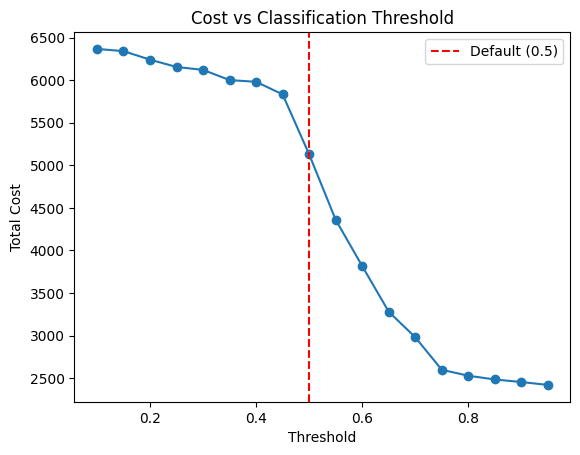

Optimal threshold: 0.95
Optimal cost: 2420
Default cost (0.5): 5128


In [82]:
# Refit on v1 reduced — final model
dt_final.fit(X_train_v1_reduced, y_train)

# Get probabilities
y_proba = dt_final.predict_proba(X_test_v1_reduced)[:, 1]  # P(On Time)

# Try different thresholds
thresholds = np.arange(0.1, 1.0, 0.05)
costs = []

for threshold in thresholds:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    cost_thresh = np.sum(cm_thresh * cost_matrix)
    costs.append(cost_thresh)

# Plot
plt.plot(thresholds, costs, marker="o")
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("Cost vs Classification Threshold")
plt.axvline(x=0.5, color="red", linestyle="--", label="Default (0.5)")
plt.legend()
plt.show()

# Find optimal threshold
optimal_idx = np.argmin(costs)
print(f"Optimal threshold: {thresholds[optimal_idx]:.2f}")
print(f"Optimal cost: {costs[optimal_idx]}")

y_pred_default = (y_proba >= 0.5).astype(int)
default_cost = np.sum(cm_dt_final * cost_matrix)
print(f"Default cost (0.5): {default_cost}")


Cost decreases monotonically as threshold increases. This is because the model was optimized for cost and incentivized to predict late for everything (as FP cost of 10 is greater than FN cost of 2). This threshold value of 0.95 is almost as good as dummy classifier (which predicted every delivery as late with total cost of only 1774.). 

In [83]:
for t, c in zip(thresholds, costs):
    y_pred_t = (y_proba >= t).astype(int)
    n_positive = y_pred_t.sum()
    print(f"Threshold: {t:.2f} → Cost: {c} → On Time predictions: {n_positive}")

Threshold: 0.10 → Cost: 6366 → On Time predictions: 1388
Threshold: 0.15 → Cost: 6340 → On Time predictions: 1383
Threshold: 0.20 → Cost: 6240 → On Time predictions: 1367
Threshold: 0.25 → Cost: 6154 → On Time predictions: 1350
Threshold: 0.30 → Cost: 6120 → On Time predictions: 1343
Threshold: 0.35 → Cost: 6000 → On Time predictions: 1319
Threshold: 0.40 → Cost: 5980 → On Time predictions: 1305
Threshold: 0.45 → Cost: 5832 → On Time predictions: 1277
Threshold: 0.50 → Cost: 5128 → On Time predictions: 1065
Threshold: 0.55 → Cost: 4360 → On Time predictions: 849
Threshold: 0.60 → Cost: 3816 → On Time predictions: 647
Threshold: 0.65 → Cost: 3280 → On Time predictions: 507
Threshold: 0.70 → Cost: 2980 → On Time predictions: 375
Threshold: 0.75 → Cost: 2598 → On Time predictions: 272
Threshold: 0.80 → Cost: 2528 → On Time predictions: 259
Threshold: 0.85 → Cost: 2484 → On Time predictions: 245
Threshold: 0.90 → Cost: 2454 → On Time predictions: 236
Threshold: 0.95 → Cost: 2420 → On Time 

Threshold analysis revealed that increasing the classification threshold from 0.50 to 0.55 reduced total cost by 768 (5,134 → 4,366) while maintaining 846 On Time predictions — close to the actual 887 on-time deliveries in the test set. Beyond 0.65, On Time predictions dropped below 57% of actual cases, approaching dummy classifier behaviour where cost reduction is achieved by avoiding positive predictions rather than genuine model improvement. A threshold of *0.55* is therefore recommended as the practical optimum — balancing cost reduction with meaningful classification utility.

#### Random Forest

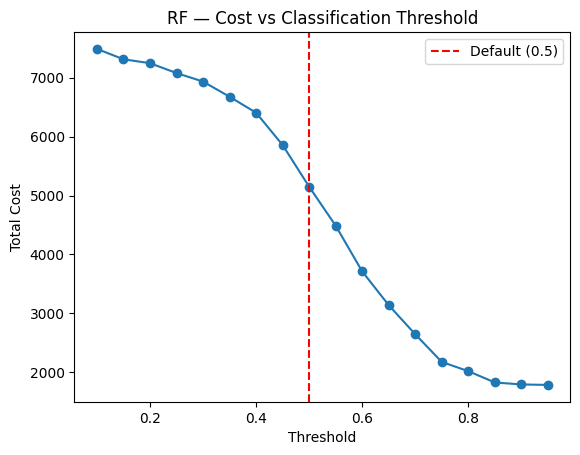

Optimal threshold: 0.95
Optimal cost: 1784
Default cost: 5150


In [84]:
# Get probabilities from rf_final
y_prob_rf_final = rf_final.predict_proba(X_test_v1_reduced_rf)[:, 1]

# Try different thresholds
thresholds = np.arange(0.1, 1.0, 0.05)
costs = []

for threshold in thresholds:
    y_pred_thresh = (y_prob_rf_final >= threshold).astype(int)
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    cost_thresh = np.sum(cm_thresh * cost_matrix)
    costs.append(cost_thresh)

# Plot
plt.plot(thresholds, costs, marker="o")
plt.xlabel("Threshold")
plt.ylabel("Total Cost")
plt.title("RF — Cost vs Classification Threshold")
plt.axvline(x=0.5, color="red", linestyle="--", label="Default (0.5)")
plt.legend()
plt.show()

# Find optimal
optimal_idx = np.argmin(costs)
print(f"Optimal threshold: {thresholds[optimal_idx]:.2f}")
print(f"Optimal cost: {costs[optimal_idx]}")
print(f"Default cost: {costs[list(np.round(thresholds,2)).index(0.5)]}")

In [85]:
for t, c in zip(thresholds, costs):
    y_pred_t = (y_prob_rf_final >= t).astype(int)
    n_positive = y_pred_t.sum()
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)
    rec0_t = recall_score(y_test, y_pred_t, pos_label=0, zero_division=0)
    print(f"Threshold: {t:.2f} → Cost: {c} → On Time: {n_positive} → F1: {f1_t:.3f} → Recall_0: {rec0_t:.3f}")

Threshold: 0.10 → Cost: 7490 → On Time: 1636 → F1: 0.703 → Recall_0: 0.430
Threshold: 0.15 → Cost: 7314 → On Time: 1616 → F1: 0.707 → Recall_0: 0.443
Threshold: 0.20 → Cost: 7248 → On Time: 1607 → F1: 0.708 → Recall_0: 0.449
Threshold: 0.25 → Cost: 7080 → On Time: 1577 → F1: 0.708 → Recall_0: 0.463
Threshold: 0.30 → Cost: 6936 → On Time: 1535 → F1: 0.701 → Recall_0: 0.478
Threshold: 0.35 → Cost: 6678 → On Time: 1466 → F1: 0.691 → Recall_0: 0.503
Threshold: 0.40 → Cost: 6406 → On Time: 1374 → F1: 0.671 → Recall_0: 0.532
Threshold: 0.45 → Cost: 5858 → On Time: 1228 → F1: 0.646 → Recall_0: 0.585
Threshold: 0.50 → Cost: 5150 → On Time: 1030 → F1: 0.602 → Recall_0: 0.655
Threshold: 0.55 → Cost: 4488 → On Time: 815 → F1: 0.532 → Recall_0: 0.724
Threshold: 0.60 → Cost: 3712 → On Time: 579 → F1: 0.438 → Recall_0: 0.804
Threshold: 0.65 → Cost: 3138 → On Time: 374 → F1: 0.314 → Recall_0: 0.866
Threshold: 0.70 → Cost: 2644 → On Time: 207 → F1: 0.183 → Recall_0: 0.919
Threshold: 0.75 → Cost: 2174 

Consistent with the Decision Tree analysis, threshold 0.55 is identified as the practical optimum for Random Forest — reducing cost from 5,150 to 4,488 while maintaining 815 On Time predictions (92% of actual 887). Beyond 0.60, F1 drops sharply indicating the model approaches dummy behaviour. The 0.55 threshold finding is consistent across both models, suggesting this reflects a natural decision boundary in the dataset.

## Explanation

*	Apply ICE/IME/SHAPLEY/Anchors to explain the classification of the instance

### Decision Tree

Sum check: 0.7499999999999996
Expected: 0.75


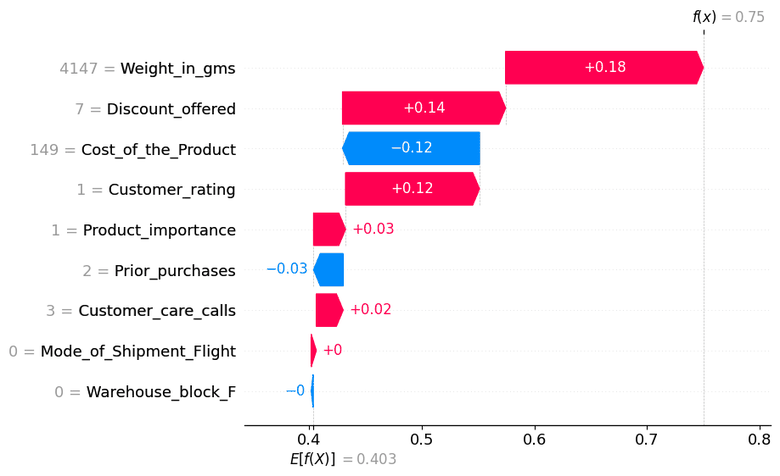

In [86]:
# Redefine dt_viz on unscaled data
dt_viz = DecisionTreeClassifier(
    criterion="gini",
    max_depth=15,
    min_samples_split=5,
    random_state=42
)
dt_viz.fit(X_train_v1_reduced_unscaled, y_train)


# Verify SHAP sum
explainer = shap.TreeExplainer(dt_viz)
shap_vals = explainer.shap_values(instance_reduced)
vals_class1 = shap_vals[0, :, 1]
base_class1 = explainer.expected_value[1]
print("Sum check:", base_class1 + vals_class1.sum())
print("Expected: 0.75")

#Plot
shap.waterfall_plot(
    shap.Explanation(
        values=vals_class1,
        base_values=base_class1,
        data=instance_reduced.iloc[0],
        feature_names=instance_reduced.columns.tolist()
    )
)

SHAP analysis of instance 4143 revealed that Weight_in_gms (4,147g, contribution=+0.18) and Discount_offered (7, contribution=+0.16) were the two strongest factors driving the On Time prediction — both pushing above the baseline probability of 0.403. Customer_rating (contribution=+0.12) provided additional support while Cost_of_the_Product (149, contribution=-0.11) partially counteracted these signals. The combined effect raised the prediction probability from 0.403 to 0.75. Despite this confident On Time prediction, the actual outcome was Late — a false positive — suggesting that the model's dominant features (weight and discount) did not capture the underlying cause of delay for this specific instance.

### Random Forest

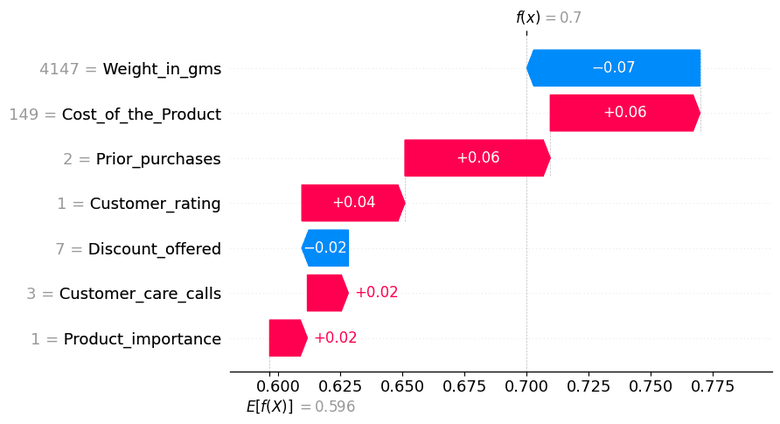

In [87]:
# Calculate SHAP
explainer_rf = shap.TreeExplainer(rf_final)
shap_vals_rf = explainer_rf.shap_values(instance_reduced_rf)  

# for display with unscaled values
instance_reduced_rf_unscaled = instance_encoded[selected_features_rf]

shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_rf[0, :, 0],
        base_values=explainer_rf.expected_value[0],
        data=instance_reduced_rf_unscaled.iloc[0],  # ← unscaled for display
        feature_names=instance_reduced_rf_unscaled.columns.tolist()
    )
)

SHAP analysis revealed why the two models disagreed on instance 4143. The Decision Tree was dominated by Weight_in_gms (+0.18) and Discount_offered (+0.16) — both pushing strongly toward On Time. The Random Forest showed a more distributed pattern — Weight_in_gms weakly pushed away from Late (-0.07) while Cost_of_the_Product (+0.06) and Prior_purchases (+0.06) pushed toward Late. The RF's ability to leverage multiple weaker signals explains its correct Late prediction.

# Final checklist

-	Are all preprocessing steps justified?
-	Did you try different metaparameter values where appropriate?
-	Are the results replicable? If you have the same data, does the report describe all steps in sufficient detail to obtain the same results as reported by the authors?
-	Were proper evaluation metrics selected? Are the results correctly interpreted?
-	Are all important steps explained and justified?
-	What is the quality of writing? Is the language clear and concise?


# Submission

* This .ipynb file with your code + its html version after the code was run (File-Save and export notebook as - html)
* Source data or a link to source data or source data being loaded from a url in the notebook
* Data files after preprorcessing (train.csv and test.csv)